In [1]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import scipy.stats
import scipy.optimize
from scipy.spatial.distance import cdist
from scipy.interpolate import interp1d
from scipy.integrate import simpson, trapezoid
from mpl_toolkits.axes_grid1 import Divider, Size
from skopt.space import Space
from skopt.sampler import Sobol, Lhs, Halton, Hammersly
from itertools import combinations, permutations, product
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn import preprocessing
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (RBF, Matern, RationalQuadratic,
                                                  ExpSineSquared, DotProduct,
                                                  ConstantKernel, WhiteKernel)

In [3]:
# Function to compute the modified right Cauchy-Green deformation tensor, given the deformation gradiant tensor is
# provided as a list. Each list element of the deformation gradient and its rate tensors are written in the
# [11, 12, 13, 21, 22, 23, 31, 32, 33] vector format.

def right_cauchy_green(F):
    C, C_bar = [], []
    
    for i in range(len(F)):
        F_temp = np.array([[F[i][0], F[i][1], F[i][2]],
                           [F[i][3], F[i][4], F[i][5]],
                           [F[i][6], F[i][7], F[i][8]]])
        C_temp = np.transpose(F_temp) @ F_temp
        # J_temp = np.linalg.det(F_temp)
        J_temp = 1
        F_bar_temp = (J_temp ** (-1/3)) * F_temp
        
        C_bar_temp = np.transpose(F_bar_temp) @ F_bar_temp
        
        C.append(C_temp)
        C_bar.append(C_bar_temp)
        
    return C, C_bar

In [4]:
# Function to compute the modified strain invariants from the deformation gradient tensors provided as a list.
# Each list element of the deformation gradient tensor is written in the [11, 12, 13, 21, 22, 23, 31, 32, 33]
# vector format.

def invariants(F):
    I1_bar, I2_bar, J = [], [], []
        
    for i in range(len(F)):
        F_temp = np.array([[F[i][0], F[i][1], F[i][2]],
                           [F[i][3], F[i][4], F[i][5]],
                           [F[i][6], F[i][7], F[i][8]]])
        # J_temp = np.linalg.det(F_temp)
        J_temp = 1
        F_bar_temp = (J_temp ** (-1/3)) * F_temp
        
        C_bar_temp = np.transpose(F_bar_temp) @ F_bar_temp
        C_bar_temp_2 = C_bar_temp @ C_bar_temp
        C_temp = np.transpose(F_temp) @ F_temp

        
        I1_bar.append(np.trace(C_bar_temp))
        I2_bar.append(0.5 * (np.trace(C_bar_temp)**2 - np.trace(C_bar_temp_2)))
        J.append(J_temp)
        
    return I1_bar, I2_bar, J

In [5]:
# Computes the referential deviatoric component of a given matrix (rank-2 tensor), Z.

def ref_deviatoric(Z, C):
    
    Dev_Z = Z - ((1/3) * np.tensordot(Z,C) * np.linalg.inv(C))
    
    return Dev_Z

In [6]:
# NOTE: THIS FUNCTION IS NOT USED FOR UNIAXIAL TEST DATA WITH INCOMPRESSIBILITY ASSUMPTION.

# Function to compute the irreducible integrity bases of the hyperelastic 2nd PK stress, given the deformation
# gradient tensors and the corresponding 2nd PK stresses provided as a list. Here, individual deformation gradients
# are in the form of a vector, and stresses are in the form of a 3x3 matrix.

# def volumetric_coefficient(C, S_vol):
#     zeta1 = []
    
#     for i in range(len(C)):
#         # Setting up the linear least squares optimization problem, A @ x = b
#         C_temp = np.array(C[i])
#         S_temp = np.array(S_vol[i])
        
#         # Considering the entire tensor with 9 components.
#         A = np.ravel(np.linalg.inv(C_temp))
#         A = np.reshape(A, (-1,1))
#         b = np.ravel(S_temp).T
#         #print(A.shape, b.shape)
#         x = scipy.optimize.lsq_linear(A, b).x
        
#         zeta1.append(x[0])
#     return np.array(zeta1)

In [7]:
# Function to compute the irreducible integrity bases of the hyperelastic 2nd PK stress, given the right Cauchy-
# -Green tensors and the corresponding 2nd PK stresses provided as a list. Here, individual right Cauchy-Green
# deformation and stress tensors are in the form of a 3x3 matrix.

def hyperelastic_coefficients(C, S_h):
    gamma1, gamma2 = [], []
    
    for i in range(len(C)):
        # Setting up the linear least squares optimization problem, A @ x = b
        C_temp = np.array(C[i])
        Dev_1_temp = ref_deviatoric(np.eye(3), C_temp) # This is G2 (Second component of the integrity basis).
        # J_temp = np.sqrt(np.linalg.det(C_temp))
        J_temp = 1
        C_bar_temp = (J_temp ** (-2/3)) * C_temp
        
        Dev_C_bar_temp = ref_deviatoric(C_bar_temp, C_temp) # This is G3 (Third component of the integrity basis).
        S_temp = np.array(S_h[i])

        # Calculating the components of A considering the Lagrange multiplier (uniaxial tension)
        C_inv_temp = np.linalg.inv(C_temp)
        A_1 = Dev_1_temp - ((Dev_1_temp[2,2] / C_inv_temp[2,2]) * C_inv_temp)
        A_2 = Dev_C_bar_temp - ((Dev_C_bar_temp[2,2] / C_inv_temp[2,2]) * C_inv_temp)
        
        # Considering the entire tensor with 9 components.
        A = np.vstack((np.ravel(A_1), np.ravel(A_2))).T
        #b = np.ravel(S_temp).T
        b = np.ravel(J_temp ** (2/3) * S_temp).T
        #x = scipy.optimize.lsq_linear(A, b).x
        x = scipy.optimize.lsq_linear(A, b, tol=1e-12, max_iter = 10000).x
        gamma1.append(x[0])
        gamma2.append(x[1])
        
        
        # Considering only the three non-zero components of stress.
        # b = J_temp ** (2/3) * np.array([S_temp[0,0], S_temp[1,1], S_temp[2,2]]).T
        # A = np.vstack((np.array([Dev_1_temp[0,0], Dev_1_temp[1,1], Dev_1_temp[2,2]]),
        #                np.array([Dev_C_bar_temp[0,0], Dev_C_bar_temp[1,1], Dev_C_bar_temp[2,2]]))).T
        # x = scipy.optimize.lsq_linear(A, b, tol=1e-12, max_iter = 10000).x
        # gamma1.append(x[0])
        # gamma2.append(x[1])
        
    return np.array(gamma1), np.array(gamma2)

In [8]:
# Function to compute the damage factor Chi (d(psi)/dW) of the 2nd PK stress, given the hyperelastic 2nd PK stress,
# and the corresponding total 2nd PK stresses provided as a list. Here, individual stresses are in the form of
# 3x3 matrices.

def damage_coefficients(S_h, S):
    xi = []
    for i in range(len(S_h)):
        S_h_temp = np.array(S_h[i])
        S_temp = np.array(S[i])
        # Considering the entire tensor with 9 components.
        A = np.ravel(S_h_temp).T
        A = A.reshape(-1,1)
        b = np.ravel(S_temp).T

        x = scipy.optimize.lsq_linear(A, b, tol=1e-12, max_iter = 10000).x
        xi.append(x)
        
    return np.array(xi)

In [9]:
# Function to compute strain energy density by integrating hyperelastic stress component, S_h, with respect to
# dC (increment in the right Cauchy-Green deformation tensor. W = integration of (S_h/2):dC from I to C.
def strain_energy_density(C, S_h):
    W = []
    W_temp = 0
    W.append(W_temp)
    for i in range(1,len(C)):
        dC = C[i] - C[i-1]
        #W_temp = W_temp + np.tensordot((S_h[i]/2),dC) # Forward Euler Scheme
        W_temp = W_temp + np.tensordot(((S_h[i]+S_h[i-1])/4),dC) # Trapezoidal Rule
        W.append(W_temp)
    return W

In [10]:
# Spline + adaptive quadrature method
from scipy.interpolate import CubicSpline
from scipy.integrate import quad
from typing import Optional

def energy_spline_adaptive(C_list, S_list, t: Optional[np.ndarray] = None, atol=1e-10, rtol=1e-10):
    """
    Build cubic splines for each independent component of C(t) and S(t), then integrate
    f(t) = 0.5 * S(t) : dC/dt(t) over t0..tN with adaptive quadrature.

    Returns cumulative W as a list.
    Requires SciPy.
    """
    assert CubicSpline is not None and quad is not None, "SciPy is required for the spline+adaptive method."
    C = np.array(C_list, dtype=float)
    S = np.array(S_list, dtype=float)
    N = C.shape[0]

    if t is None:
        t = _arc_length_param(C)
    else:
        t = np.asarray(t, dtype=float)
        assert t.shape == (N,)
    assert np.all(np.diff(t) > 0)

    idxs = [(0, 0), (1, 1), (2, 2), (0, 1), (0, 2), (1, 2)]
    C_spl = []
    S_spl = []
    for (i, j) in idxs:
        C_spl.append(CubicSpline(t, C[:, i, j], bc_type="natural"))
        S_spl.append(CubicSpline(t, S[:, i, j], bc_type="natural"))

    def f(tt: float) -> float:
        val = 0.0
        for k in range(6):
            val += S_spl[k](tt) * C_spl[k].derivative()(tt)
        return 0.5 * val

    W = [0.0]
    for i in range(1, N):
        Wi, _ = quad(f, float(t[i - 1]), float(t[i]), epsabs=atol, epsrel=rtol, limit=200)
        W.append(W[-1] + Wi)
    return W

In [11]:
# Gauss-Legendre per interval method.
def energy_gauss_per_interval(C_list, S_list, t: Optional[np.ndarray] = None, order: int = 2):
    """
    Per-interval Gauss-Legendre quadrature of f(t)=0.5*S(t):dC/dt over each [t_i, t_{i+1}].
    Returns cumulative W as a list.
    """
    assert order in (2, 3)
    C = np.array(C_list, dtype=float)
    S = np.array(S_list, dtype=float)
    N = C.shape[0]

    if t is None:
        t = _arc_length_param(C)
    else:
        t = np.asarray(t, dtype=float)
        assert t.shape == (N,)
    assert np.all(np.diff(t) > 0)

    if order == 2:
        xi = np.array([-1/np.sqrt(3), 1/np.sqrt(3)])
        w = np.array([1.0, 1.0])
    else:
        xi = np.array([-np.sqrt(3/5), 0.0, np.sqrt(3/5)])
        w = np.array([5/9, 8/9, 5/9])

    W = [0.0]
    for i in range(1, N):
        t0, t1 = t[i - 1], t[i]
        dt = t1 - t0
        dC = C[i] - C[i - 1]
        dCdt = dC / dt

        S0, S1 = S[i - 1], S[i]
        dS = S1 - S0
        accum = 0.0
        tg = 0.5 * (t1 + t0) + 0.5 * dt * xi
        for g in range(len(w)):
            alpha = (tg[g] - t0) / dt
            Sg = S0 + alpha * dS
            #accum += w[g] * _frobenius_dot(Sg, dCdt)
            accum += w[g] * float(np.tensordot(Sg, dCdt))
        Wi = 0.5 * (0.5 * dt) * accum
        W.append(W[-1] + Wi)
    return W

In [13]:
import pandas as pd
data = pd.read_csv('../data/brain_wm_p.csv') # Details: White Matter_parietal lobe_13mm-8mm prismatic_frontal dir

data = data.to_numpy()
stretch_raw = data[:,0]
stress_raw = data[:,1] # Nominal stress (1st PK).

N = 101
F11_train = np.linspace(np.min(stretch_raw),np.max(stretch_raw), N)
interp_data = interp1d(stretch_raw,stress_raw)
S11_training = interp_data(F11_train)/F11_train # Divide by stretch to get the 2nd PK stress.

F_training = []

for i in range(N):
    F_training.append(np.array([F11_train[i], 0, 0, 0, (1/np.sqrt(F11_train[i])), 0, 0, 0, (1/np.sqrt(F11_train[i]))]))

I1_training, I2_training, J_training = invariants(F_training)
C_training, C_bar_training = right_cauchy_green(F_training)

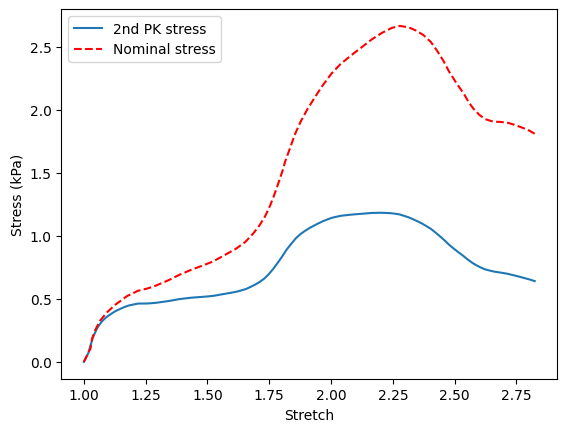

In [14]:
plt.plot(F11_train, S11_training, label = '2nd PK stress')
plt.plot(stretch_raw, stress_raw,'r--', label = 'Nominal stress')
plt.legend()
plt.ylabel('Stress (kPa)')
plt.xlabel('Stretch')
plt.show()

In [15]:
#F11_train, np.where(F11_train<=(np.max(F11_train)+1)/2), F11_train[np.where(F11_train<=(np.max(F11_train)+1)/2)]#, F11_train[27] # This is nearly half of the peak stretch (2.75).

C:\Users\kshit\AppData\Local\Temp\ipykernel_68376\991136268.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, prop={'size': 8})


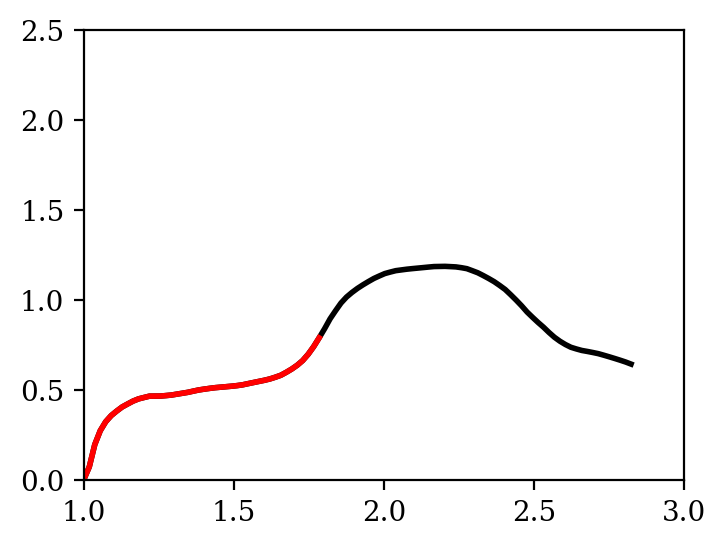

In [20]:
# Plot 1b. Training data.
plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)
#ax = fig.add_subplot(1, 1, 1)

plt.xlim([1, 3])
plt.ylim([0, 2.5])

ax.plot(F11_train, S11_training, c = 'k', linewidth = 2) #marker = 'o', markersize = '5', 
id = np.where(F11_train<=(np.max(F11_train)+1)/2 - 0.11)
ax.plot(F11_train[id], S11_training[id], c = 'r', linewidth = 2) # Up to half the peak stretch
#plt.ylim((-0.2, 0.1))

#ax.set_xlabel('$\lambda$')
#ax.set_ylabel('$S_{h,\mathrm{iso, 11}}$, $S_{h,\mathrm{iso, 22}}$')
ax.legend(frameon=False, prop={'size': 8})
#plt.savefig("Experimental_training_data_WM_parietal lobe_13mm-8mm prismatic_frontal_dir.svg")
#plt.savefig("Hyperelastic_training_fitting.svg")
plt.show()

In [21]:
print((np.max(F11_train)+1)/2 - 0.11)

1.80205


In [22]:
# Hyperelastic regime (no damage)
N_h = np.shape(id)[1] # Assuming the stress-strain data for training is hyperelastic up to half the max. stretch.

input_training_GPR_iso_h = np.vstack((np.array(I1_training), np.array(I2_training))).T # This will be used later to train the single stage GPR model.

F_h_training = []

for i in range(N_h):
    F_h_training.append(F_training[i])
    # F_h_training.append(np.array([F11_train[i], 0, 0, 0, (1/np.sqrt(F11_train[i])), 0, 0, 0, (1/np.sqrt(F11_train[i]))]))

I1_h_training, I2_h_training, J_h_training = invariants(F_h_training)
C_h_training, C_h_bar_training = right_cauchy_green(F_h_training)
input_h_training_GPR_iso_h = np.vstack((np.array(I1_h_training), np.array(I2_h_training))).T

In [23]:
F_h_training[-1]

array([1.784363  , 0.        , 0.        , 0.        , 0.74861478,
       0.        , 0.        , 0.        , 0.74861478])

In [24]:
# Generating stress tensors for training the GPR model of step 1.

S_training = []

for i in range(len(F_training)):
    S_training.append(np.array([[S11_training[i], 0., 0.], [0., 0., 0.], [0., 0., 0.]]))

In [25]:
# NOTE: THIS FUNCTION IS NOT USED FOR UNIAXIAL TEST DATA WITH INCOMPRESSIBILITY ASSUMPTION.
# # Stress data generation artifically using the MR + Siemo-Miehe + Volokh model.

# A10, A01 = 1, 0.5 # MR model parameters
# # kappa = 2*2*(A10 + A01)*(1 + nu)/(3*(1 - 2*nu)) # Siemo-Miehe model parameter (bulk modulus)
# kappa = 100
# phi, m = 0.75, 10 # Volokh model parameters (pseudo-failure energy and sharpness parameter, respectively)

# S_training = [] # Full training dataset: Hyperelasticity + Damage.
# S_training_vol = []
# S_training_iso_h = []
# W_h = []
# Xi_1 = []
# for i in range(len(F_training)):
#     S_h_MR = 2 * (J_training[i] ** (-2/3)) * ((A10 + (I1_training[i] * A01)) * ref_deviatoric(np.eye(3), C_training[i]) - A01 * ref_deviatoric(C_bar_training[i], C_training[i]))
#     S_h_SM = (kappa/2) * (J_training[i]**2 - 1) * np.linalg.inv(C_training[i])
#     S_h = S_h_MR + S_h_SM
#     # S_training_vol.append(S_h_SM)
#     # S_training_iso_h.append(S_h_MR)
    
#     W_h_MR = A10 * (I1_training[i] - 3) + A01 * (I2_training[i] - 3)
#     W_h_SM = (kappa/2) * (((J_training[i]**2 - 1)/2) - np.log(J_training[i]))
#     W_h.append(W_h_MR + W_h_SM)
#     S_training_vol.append(np.exp(-((W_h[i]/phi)**m)) * S_h_SM)
#     S_training_iso_h.append(np.exp(-((W_h[i]/phi)**m)) * S_h_MR)
#     S_training.append(np.exp(-((W_h[i]/phi)**m)) * S_h)

#     Xi_1.append(np.exp(-((W_h[i]/phi)**m)))

In [26]:
# Now generating output training data for the GPR#1 (vol) and GPR#2 (iso,h) models.

# Hyperelastic stress in the undamaged material (assumed to be up to half of the peak stretch).
S_h_training = []
# S_h_training_vol = []
# S_h_training_iso_h = []

for i in range(N_h):
    S_h_training.append(S_training[i])
    # S_h_training_vol.append(S_training_vol[i])
    # S_h_training_iso_h.append(S_training_iso_h[i])

# zeta1 = volumetric_coefficient(C_training, S_training_vol)
# output_training_GPR_vol = np.reshape(zeta1.T,(-1,1)) # This will be used later to train the single stage GPR model.

# Output data of the GPR#1 model.
# zeta1_h = volumetric_coefficient(C_h_training, S_h_training_vol)
# output_h_training_GPR_vol = np.reshape(zeta1_h.T,(-1,1))

gamma1, gamma2 = hyperelastic_coefficients(C_training, S_training)
output_training_GPR_iso_h = np.vstack((gamma1, gamma2)).T # This will be used later to train the single stage GPR model.

# Output data of the GPR#2 model.
gamma1_h, gamma2_h = hyperelastic_coefficients(C_h_training, S_h_training)
output_h_training_GPR_iso_h = np.vstack((gamma1_h, gamma2_h)).T

In [27]:
# # # Output training data generation: Irreducible integrity bases. This data is generated artifically using the Gent
# # # model.

# mu, Jm = 1, 1
# S_training = []

# for i in range(len(F_training)):
#     S_training.append((J_training[i] ** (-2/3)) * (mu / (1 - ((input_training[i,0] - 3) / Jm ))) * ref_deviatoric(np.eye(3), C_training[i]))

# gamma1, gamma2 = hyperelastic_coefficients(C_training, S_training)
# output_training = np.vstack((gamma1, gamma2)).T

In [28]:
# Output training data generation: Irreducible integrity bases. This data is generated artifically using the Gent-Gent
# model.

# mu, Jm, C2 = 1, 0.35, -0.25
# S_training = []

# for i in range(len(F_training)):
#     S_training.append((J_training[i] ** (-2/3)) * ((((mu / (1 - ((input_training[i,0] - 3) / Jm ))) + (3*C2*(input_training[i,0]/input_training[i,1]))) * ref_deviatoric(np.eye(3), C_training[i])) - 
#                      (3*C2/input_training[i,1]) * ref_deviatoric(C_bar_training[i], C_training[i])))

# gamma1, gamma2 = hyperelastic_coefficients(C_training, S_training)
# output_training = np.vstack((gamma1, gamma2)).T

In [29]:
# The neo-Hookean volumetric + two-term Yeoh + one-term Volokh1 damage model (S11 component)

def nh_yeoh_damage1_S11(X, C1, C2, phi1):
    F = X # F_training as a list is the input.
    C,_ = right_cauchy_green(F)
    I1_bar, _, _ = invariants(F)
    S11 = []
    for i in range(len(F)):
        #W = ((K/2) * (J[i] - 1)**2) + (C1 * (I1_bar[i] - 3)) + (C2 * ((I1_bar[i] - 3)**2))
        W = (C1 * (I1_bar[i] - 3)) + (C2 * ((I1_bar[i] - 3)**2))

        # Integrity Basis components
        G1_temp = np.linalg.inv(C[i])
        G2_temp = ref_deviatoric(np.eye(3), C[i])
        
        S11.append(np.exp(-W/phi1) * ((2*C1 + 4*C2*(I1_bar[i] - 3)) * 
                                       (G2_temp[0][0] - (G2_temp[1][1]/G1_temp[1][1]) * 
                                        G1_temp[0][0])))

        #S11.append(np.exp(-W/phi1) * (J[i]**(-2/3)) * (2*C1 + 4*C2*(I1_bar[i] - 3))
        #           * ref_deviatoric(np.eye(3), C[i])[0][0])
    
    return np.array(S11)

In [30]:
# The neo-Hookean volumetric + two-term Yeoh + one-term Volokh1 damage model (the full stress tensor)

def nh_yeoh_damage1_S(X, C1, C2, phi1):
    F = X # F_training as a list is the input.
    C,_ = right_cauchy_green(F)
    I1_bar, _, _ = invariants(F)
    S11, S22, S33 = [], [], []
    for i in range(len(F)):
        #W = ((K/2) * (J[i] - 1)**2) + (C1 * (I1_bar[i] - 3)) + (C2 * ((I1_bar[i] - 3)**2))
        W = (C1 * (I1_bar[i] - 3)) + (C2 * ((I1_bar[i] - 3)**2))
        
        # S11.append(np.exp(-W/phi1) * ((K*J[i]*(J[i] - 1)* np.linalg.inv(C[i])[0][0]) +
        #     ((J[i]**(-2/3)) * (2*C1 + 4*C2*(I1_bar[i] - 3))
        #            * ref_deviatoric(np.eye(3), C[i])[0][0])))
        # Integrity Basis components
        G1_temp = np.linalg.inv(C[i])
        G2_temp = ref_deviatoric(np.eye(3), C[i])
        
        S11.append(np.exp(-W/phi1) * ((2*C1 + 4*C2*(I1_bar[i] - 3)) * 
                                       (G2_temp[0][0] - (G2_temp[1][1]/G1_temp[1][1]) * 
                                        G1_temp[0][0])))
        S22.append(np.exp(-W/phi1) * ((2*C1 + 4*C2*(I1_bar[i] - 3)) * 
                                       (G2_temp[1][1] - (G2_temp[1][1]/G1_temp[1][1]) * 
                                        G1_temp[1][1])))
        S33.append(np.exp(-W/phi1) * ((2*C1 + 4*C2*(I1_bar[i] - 3)) * 
                                       (G2_temp[2][2] - (G2_temp[1][1]/G1_temp[1][1]) * 
                                        G1_temp[2][2])))
    
    return np.vstack((S11, S22, S33)).T.flatten()

In [31]:
# Fitting the 1-term volumetric NH + 2-term Yeoh + 1 term old Volokh model (defined above) to the generated
# training stress data.

S11_training, S22_training = [], []
# S11_training_vol, S22_training_vol = [], []
# S11_training_iso_h, S22_training_iso_h = [], []
for i in range(len(S_training)):
    S11_training.append(S_training[i][0,0])
    S22_training.append(S_training[i][1,1])
    # S11_training_vol.append(S_training_vol[i][0,0])
    # S22_training_vol.append(S_training_vol[i][1,1])
    # S11_training_iso_h.append(S_training_iso_h[i][0,0])
    # S22_training_iso_h.append(S_training_iso_h[i][1,1])

# popt, pcov = scipy.optimize.curve_fit(nh_yeoh_damage1_S11, F_training, np.array(S11_training), bounds=([0,0,0,0], [inf, inf, inf, inf]))
#popt, pcov = scipy.optimize.curve_fit(nh_yeoh_damage1_S11, F_training, np.array(S11_training))

# Alternatively, fitting with the full stress-strain data.
popt, pcov = scipy.optimize.curve_fit(nh_yeoh_damage1_S, F_training, np.vstack((S11_training, S22_training, S22_training)).T.flatten())

C1_YH = popt[0]
C2_YH = popt[1]
phi1 = popt[2]

In [32]:
S_yh = nh_yeoh_damage1_S(F_training, popt[0], popt[1], popt[2])
S_yh.reshape(-1,3).shape
C1_YH, C2_YH, phi1

(np.float64(0.28553866527682026),
 np.float64(0.14158096176775078),
 np.float64(3.3665515479993946))

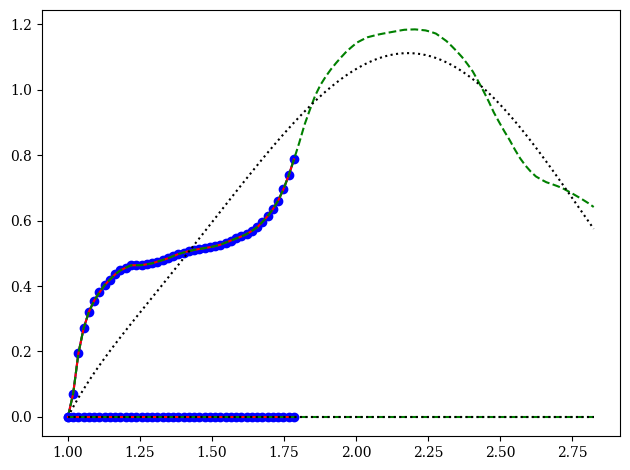

In [33]:
# Testing the accuracy of the generation of outputs (i.e., zeta1, and gamma1, gamma2) 
S11_h_training, S22_h_training = [], []
for i in range(len(S_h_training)):
    S11_h_training.append(S_h_training[i][0,0])
    S22_h_training.append(S_h_training[i][1,1])

# The recreated response from the generated gamma 1, gamma 2 training data.
# S_h_SM_rec = []
# S_h_MR_rec = []
S_h_total_rec = []
S_h_total_rec_V2 = []

# S11_h_SM_rec, S22_h_SM_rec = [], []
# S11_h_MR_rec, S22_h_MR_rec = [], []
S11_h_total_rec, S22_h_total_rec = [], []
S11_h_total_rec_V2, S22_h_total_rec_V2 = [], []

for i in range(len(F_h_training)):
    G1_temp = np.linalg.inv(C_h_training[i])
    G2_temp = ref_deviatoric(np.eye(3), C_h_training[i])
    G3_temp = ref_deviatoric(C_h_bar_training[i], C_h_training[i])
    
    S_h_total_rec.append((gamma1_h[i] * (G2_temp - (G2_temp[1][1]/G1_temp[1][1]) * G1_temp)) +
                        (gamma2_h[i] * (G3_temp - (G3_temp[1][1]/G1_temp[1][1]) * G1_temp)))
    
    # Alternative way to compute stress, just for validation.
    S_h_total_rec_V2.append((gamma1_h[i] * (G2_temp - ((1/3) * (1/F11_train[i] - F11_train[i]**2)) * G1_temp)) +
                        (gamma2_h[i] * (G3_temp - ((1/3) * (1/(F11_train[i]**2) - F11_train[i]**4)) * G1_temp)))
    # S_h_SM_rec.append(zeta1_h[i] * np.linalg.inv(C_h_training[i]))   
    # S_h_MR_rec.append(J_h_training[i] ** (-2/3) * (gamma1_h[i] * ref_deviatoric(np.eye(3), C_h_training[i]) + gamma2_h[i] * ref_deviatoric(C_h_bar_training[i], C_h_training[i])))
    # S_h_total_rec.append(S_h_SM_rec[i] + S_h_MR_rec[i])
    
for i in range(len(S_h_total_rec)):
    # S11_h_SM_rec.append(S_h_SM_rec[i][0,0])
    # S22_h_SM_rec.append(S_h_SM_rec[i][1,1])
    # S11_h_MR_rec.append(S_h_MR_rec[i][0,0])
    # S22_h_MR_rec.append(S_h_MR_rec[i][1,1])
    S11_h_total_rec.append(S_h_total_rec[i][0,0])
    S22_h_total_rec.append(S_h_total_rec[i][1,1])
    S11_h_total_rec_V2.append(S_h_total_rec_V2[i][0,0])
    S22_h_total_rec_V2.append(S_h_total_rec_V2[i][1,1])

S11_yh, S22_yh, S33_yh = [], [], []
S_yh = nh_yeoh_damage1_S(F_training, popt[0], popt[1], popt[2]).reshape(-1,3)
for i in range(len(F_training)):
    S11_yh.append(S_yh[i,0])
    S22_yh.append(S_yh[i,1])
    S33_yh.append(S_yh[i,2])

# S_MR_damage = []
# S11_MR_damage, S22_MR_damage = [], []
# for i in range(len(F_training)):
#     S_MR_damage.append(S_MR[i] * xi[i])  
    
# for i in range(len(S_MR_damage)):
#     S11_MR_damage.append(S_MR_damage[i][0,0])
#     S22_MR_damage.append(S_MR_damage[i][1,1])

#S11_yh = nh_yeoh_damage1_S11(F_training, popt[0], popt[1], popt[2], popt[3])
plt.plot(F11_train[:N_h], S11_h_training, color = 'b', marker = 'o')
plt.plot(F11_train[:N_h], S11_h_total_rec, color = 'r')
plt.plot(F11_train, S11_training, color = 'g', linestyle = '--')
plt.plot(F11_train, S11_yh, color = 'k', linestyle = ':')
#plt.plot(F11_train, S11_MR_damage, color = 'g', linestyle = '--')
plt.plot(F11_train[:N_h], S22_h_training, color = 'b', marker = 'o')
plt.plot(F11_train[:N_h], S22_h_total_rec, color = 'r')
plt.plot(F11_train, S22_training, color = 'g', linestyle = '--')
plt.plot(F11_train, S22_yh, color = 'k', linestyle = ':')
#plt.plot(F11_train, S22_MR_damage, color = 'g', linestyle = '--')

In [34]:
# Printing the difference between stresses calculated using the formula based on Gs (integrity basis) vs those
# calculated using lambda. The ideal value should be zero.
diff_S11 = np.array(S11_h_total_rec) - np.array(S11_h_total_rec_V2)
diff_S22 = np.array(S22_h_total_rec) - np.array(S22_h_total_rec_V2)
np.max(diff_S11), np.max(diff_S22)

(np.float64(1.6653345369377348e-16), np.float64(3.638517181136755e-16))

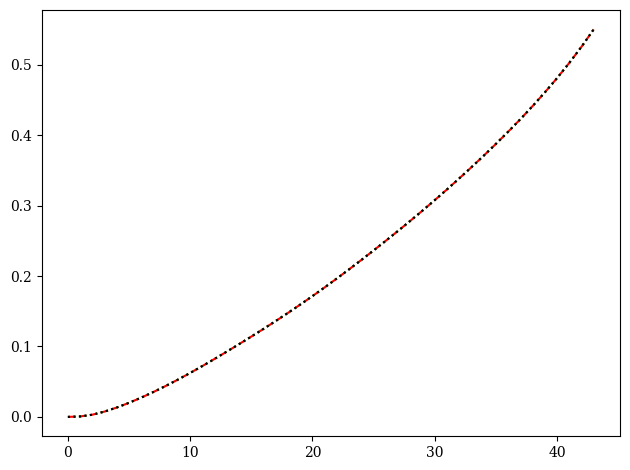

In [35]:
# Numerically computing the total strain energy density function (vol + iso,h) and comparing with the analytical
# values.
W_h_numerical = strain_energy_density(C_h_training, S_h_training) # Numerically obtained strain energy density.
psi_numerical = strain_energy_density(C_training, S_training) # Modified energy density (shows asymptotic behavior)

# Comparing numerically-computed W with alternative methods.
s = np.linspace(0.0, 1.0, N_h)
W_h_V2 = energy_spline_adaptive(C_h_training, S_h_training, t=s) # Numerically Obtained Strain energy density
W_h_V3 = energy_gauss_per_interval(C_h_training, S_h_training, t=s, order=2)

# plt.plot(W_h[:N_h],'b')
plt.plot(W_h_numerical,'r--')
plt.plot(W_h_V2,'g:')
plt.plot(W_h_V3,'k:')

In [36]:
# Building the GPR#1 model using only the volumetric hyperelastic part of the data.
kernels = [ConstantKernel(1.0, (1e-4, 1e4)) * RBF(1, (1e-6, 1e6)),
           1.0 * RationalQuadratic(length_scale=1.0, alpha=0.1),
           1.0 * ExpSineSquared(length_scale=1.0, periodicity=1,
                                length_scale_bounds=(1.0e-5, 100.0),
                                periodicity_bounds=(1.0, 10.0)),
           ConstantKernel(0.1, (0.01, 10.0))
           * (DotProduct(sigma_0=1.0, sigma_0_bounds=(0.0, 10.0)) ** 2),
           1.0 * Matern(length_scale=1.0, nu=1.5),
          1.0 * Matern(length_scale=1.0, nu=2.5),
          ConstantKernel(1.0, (1e0, 1e4)) * RBF(1, (1e0, 1e6))]

# alpha = 1.0e-2 * np.ones(input_h_training_GPR_vol.shape[0])
# alpha[0] = 1.0e-5

# Krig_1_vol = GaussianProcessRegressor(kernel=kernels[5], alpha=alpha, n_restarts_optimizer=20, normalize_y=True)
# #Krig_h = GaussianProcessRegressor(kernel=kernels[4], alpha=alpha, n_restarts_optimizer=10, normalize_y=True)

# Krig_1_vol.fit(input_h_training_GPR_vol,output_h_training_GPR_vol)
# Krig_1_vol.score(input_h_training_GPR_vol,output_h_training_GPR_vol)

In [37]:
# Building the GPR#2 model using only the isochoric hyperelastic part of the data.

alpha = 1.0e-2 * np.ones(input_h_training_GPR_iso_h.shape[0]) #KU 03092024
alpha[0] = 1.0e-5

Krig_2_iso_h = GaussianProcessRegressor(kernel=kernels[5], alpha=5e-1, n_restarts_optimizer=20, normalize_y=True)
#Krig_h = GaussianProcessRegressor(kernel=kernels[4], alpha=alpha, n_restarts_optimizer=10, normalize_y=True)

Krig_2_iso_h.fit(input_h_training_GPR_iso_h,output_h_training_GPR_iso_h)
Krig_2_iso_h.score(input_h_training_GPR_iso_h,output_h_training_GPR_iso_h)

0.6430945054165764

In [38]:
input_h_training_GPR_iso_h.shape, output_h_training_GPR_iso_h.shape

((44, 2), (44, 2))

In [39]:
# Generating the training data for the third GPR model, GPR#3, to capture progressive damage.

# Predicted volumetric stress over the entire loading regime (hyperelastic + damage).
# Predicted isochoric hyperelastic stress over the entire loading regime (hyperelastic + damage).

# S_h_GPRpred_vol = []
# S_h_GPRpred_iso_h = []
S_h_GPRpred = []
for i in range(N):
    G1_temp = np.linalg.inv(C_training[i])
    G2_temp = ref_deviatoric(np.eye(3), C_training[i])
    G3_temp = ref_deviatoric(C_bar_training[i], C_training[i])
    
    S_h_GPRpred.append((Krig_2_iso_h.predict(input_training_GPR_iso_h)[i,0] * (G2_temp - (G2_temp[1][1]/G1_temp[1][1]) * G1_temp)) +
                        (Krig_2_iso_h.predict(input_training_GPR_iso_h)[i,1] * (G3_temp - (G3_temp[1][1]/G1_temp[1][1]) * G1_temp)))
    
    
    # S_h_GPRpred_vol.append(Krig_1_vol.predict(input_training_GPR_vol)[i] * np.linalg.inv(C_training[i]))
    # S_h_GPRpred_iso_h.append(J_training[i] ** (-2/3) * (Krig_2_iso_h.predict(input_training_GPR_iso_h)[i,0] * ref_deviatoric(np.eye(3), C_training[i]) + Krig_2_iso_h.predict(input_training_GPR_iso_h)[i,1] * ref_deviatoric(C_bar_training[i], C_training[i])))
    # S_h_GPRpred.append(S_h_GPRpred_vol[i] + S_h_GPRpred_iso_h[i])

W_h_GPRpred = strain_energy_density(C_training, S_h_GPRpred)

input_training_GPR3 = np.array(W_h_GPRpred).reshape(-1,1)

xi = damage_coefficients(S_h_GPRpred, S_training)

#xi[:N_h] = damage_coefficients(S_h_training, S_training[:N_h])
xi[0] = 1 # Damage coefficient at the reference state must be unity.

output_training_GPR3 = xi
# output_training_GPR2 = xi - 1
# output_training_GPR2[0] = 0

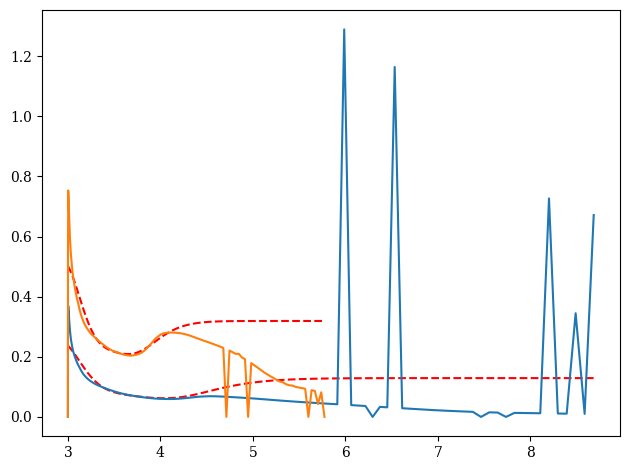

In [40]:
# plt.plot(input_training_GPR_vol, Krig_1_vol.predict(input_training_GPR_vol), 'b--')
# plt.plot(input_training_GPR_vol, output_training_GPR_vol)
# plt.show()
plt.plot(input_training_GPR_iso_h, Krig_2_iso_h.predict(input_training_GPR_iso_h), 'r--')
plt.plot(input_training_GPR_iso_h, output_training_GPR_iso_h)
plt.show()

In [41]:
# Comparing GPR-predicted and training stresses.
# S11_h_GPRpred_vol, S22_h_GPRpred_vol = [], []
# S11_h_GPRpred_iso_h, S22_h_GPRpred_iso_h = [], []
S11_h_GPRpred, S22_h_GPRpred = [], []

for i in range(N):
    # S11_h_GPRpred_vol.append(S_h_GPRpred_vol[i][0,0])
    # S22_h_GPRpred_vol.append(S_h_GPRpred_vol[i][1,1])
    # S11_h_GPRpred_iso_h.append(S_h_GPRpred_iso_h[i][0,0])
    # S22_h_GPRpred_iso_h.append(S_h_GPRpred_iso_h[i][1,1])
    S11_h_GPRpred.append(S_h_GPRpred[i][0,0])
    S22_h_GPRpred.append(S_h_GPRpred[i][1,1])

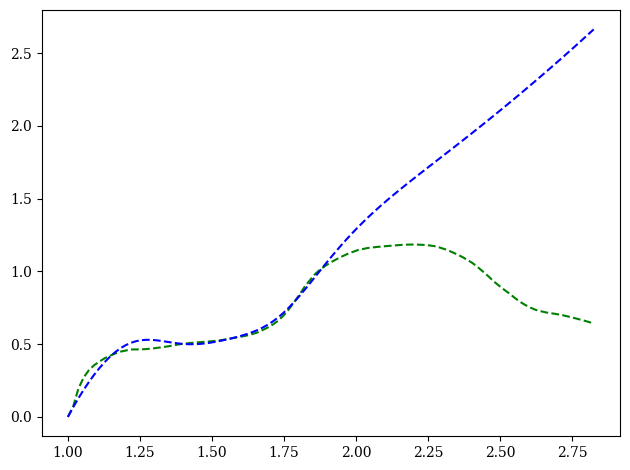

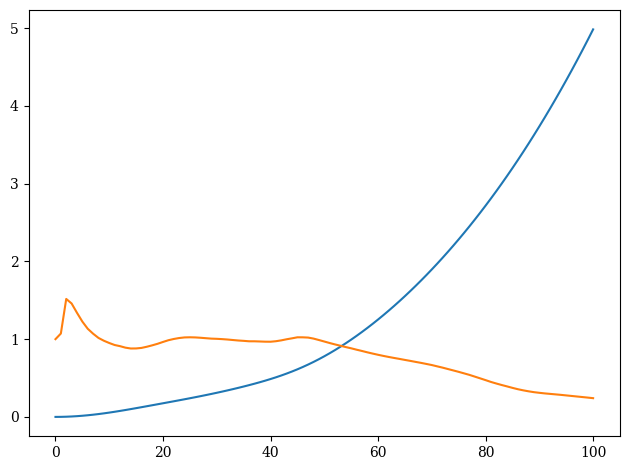

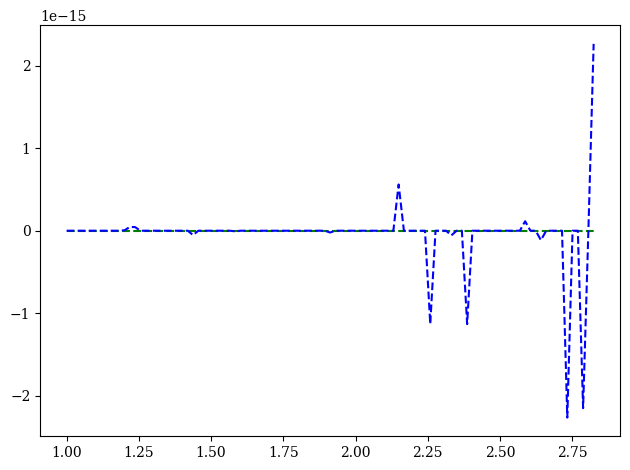

In [42]:
plt.plot(F11_train, S11_training, color = 'g', linestyle = '--')
plt.plot(F11_train, S11_h_GPRpred, color = 'b', linestyle = '--')
# plt.plot(F11_train, S11_training_vol, color = 'g', linestyle = '-')
# plt.plot(F11_train, S11_h_GPRpred_vol, color = 'b', linestyle = '-')
# plt.plot(F11_train, S11_training_iso_h, color = 'g', linestyle = ':')
# plt.plot(F11_train, S11_h_GPRpred_iso_h, color = 'b', linestyle = ':')

# plt.plot(F11_train, S22_training, color = 'g', linestyle = '-')
# plt.plot(F11_train, S22_h_GPRpred, color = 'b', linestyle = '-')
plt.show()

plt.plot(input_training_GPR3)
plt.plot(output_training_GPR3)
plt.show()

plt.plot(F11_train, S22_training, color = 'g', linestyle = '--')
plt.plot(F11_train, S22_h_GPRpred, color = 'b', linestyle = '--')
# plt.plot(F11_train, S22_training_vol, color = 'g', linestyle = '-')
# plt.plot(F11_train, S22_h_GPRpred_vol, color = 'b', linestyle = '-')
# plt.plot(F11_train, S22_training_iso_h, color = 'g', linestyle = ':')
# plt.plot(F11_train, S22_h_GPRpred_iso_h, color = 'b', linestyle = ':')

# plt.plot(F11_train, S22_training, color = 'g', linestyle = '-')
# plt.plot(F11_train, S22_h_GPRpred, color = 'b', linestyle = '-')
plt.show()

In [43]:
# Generating xi in a different way, where the initial values upto the hyperelastic regime are calculated using
# the available experimental stress-strain data, and the remaining extrapolation is done using the learned
# GPR model.

# xi[:N_h] = damage_coefficients(S_h_training, S_training[:N_h])

In [44]:
input_h_training_GPR_iso_h.shape, output_h_training_GPR_iso_h.shape, input_training_GPR3.shape, output_training_GPR3.shape

((44, 2), (44, 2), (101, 1), (101, 1))

In [45]:
# Now, training the second GPR model between the strain energy density predicted by the first model and the
# damage parameter xi.
# kernels = [ConstantKernel(1.0, (1e-4, 1e4)) * RBF(1, (1e-6, 1e6)),
#            1.0 * RationalQuadratic(length_scale=1.0, alpha=0.1),
#            1.0 * ExpSineSquared(length_scale=1.0, periodicity=1,
#                                 length_scale_bounds=(1.0e-5, 100.0),
#                                 periodicity_bounds=(1.0, 10.0)),
#            ConstantKernel(0.1, (0.01, 10.0))
#            * (DotProduct(sigma_0=1.0, sigma_0_bounds=(0.0, 10.0)) ** 2),
#            1.0 * Matern(length_scale=1.0, nu=1.5)]

# alpha = 1.0e-2 * np.ones(input_training_GPR2.shape[0]) #KU 03092024
# alpha[0] = 1.0e-4

# #Krig = GaussianProcessRegressor(kernel=kernels[4], alpha=1.0e0, n_restarts_optimizer=10, normalize_y=True)
# Krig = GaussianProcessRegressor(kernel=kernels[4], alpha=alpha, n_restarts_optimizer=10, normalize_y=True)

# Krig.fit(input_training_GPR2,output_training_GPR2)
# Krig.score(input_training_GPR2,output_training_GPR2)

In [46]:
# NOTES ON THE CHOLESKY METHOD:

# Cholesky decomposition of a Hermitian, positive-definite matrix K is the product of a lower triangular
# matrix L and its conjugate transpose, i.e., K = L @ L^T. To find a matrix inverse using the Cholesky method, we
# solve two linear equations, L @ A = I (which gives A = L^-1 @ I) and L^T @ B = A (which gives B = L^-T @L^-1 @I).
# B is the inverse of K. In the computation of the GP posterior mean, we do mu = K(z,z*)^T @ K(z,z)^-1 @ Y (Y being
# the training output data). K^-1 @ Y is obtained using the Cholesky method by solving L @ A = Y and L^T @ B = A.

# Cholesky method can also yield the determinant as the square of product of all diagonal components of L. That is,
# det(K) = (L_11*L_22*...*L_nn)^2. In the NLML (negative log marginal likelihood), we have 0.5 * log(det(K)). This
# can be obtained as log(det(K)) = 2 * (log(L_11) + log(L_22) + ... + log(L_nn)).

# Playing with the Cholesky method.
KK = np.array([[3,-1,1],[-1,3,1],[1,1,2]])
Y = np.array([[2],[1],[3]])
LL = np.linalg.cholesky(KK)# + 1e-3 * np.eye(len(KK)))
det_KK = np.exp(np.sum(np.log(np.diag(LL)**2)))
KK_inv = np.linalg.solve(LL.T, np.linalg.solve(LL, np.eye(3)))
KK_inv_Y = np.linalg.solve(LL.T, np.linalg.solve(LL, Y))
KK, numpy.linalg.inv(KK), KK_inv, KK_inv@Y, KK_inv_Y, det_KK, np.linalg.det(KK)

(array([[ 3, -1,  1],
        [-1,  3,  1],
        [ 1,  1,  2]]),
 array([[ 0.625,  0.375, -0.5  ],
        [ 0.375,  0.625, -0.5  ],
        [-0.5  , -0.5  ,  1.   ]]),
 array([[ 0.625,  0.375, -0.5  ],
        [ 0.375,  0.625, -0.5  ],
        [-0.5  , -0.5  ,  1.   ]]),
 array([[ 0.125],
        [-0.125],
        [ 1.5  ]]),
 array([[ 0.125],
        [-0.125],
        [ 1.5  ]]),
 np.float64(7.999999999999998),
 np.float64(8.000000000000002))

In [47]:
# Helper functions for monotonicity-constrained GPR model.
# === RBF Kernel and Derivatives ===
def rbf_kernel(x1, x2, lengthscale, variance):
    x1 = np.atleast_2d(x1)
    x2 = np.atleast_2d(x2)
    dists = cdist(x1, x2, 'sqeuclidean')
    return variance * np.exp(-0.5 * dists / lengthscale**2)

def rbf_kernel_dx(x1, x2, lengthscale, variance):
    x1 = np.atleast_2d(x1)
    x2 = np.atleast_2d(x2)
    diff = x1[:, None, :] - x2[None, :, :]
    base = rbf_kernel(x1, x2, lengthscale, variance)
    return (-(diff.squeeze(-1)) / lengthscale**2) * base

def rbf_kernel_dxdx(x1, x2, lengthscale, variance):
    diff = x1[:, None, :] - x2[None, :, :]
    sq_dist = np.sum(diff**2, axis=2)
    base = variance * np.exp(-0.5 * sq_dist / lengthscale**2)
    term1 = 1 / lengthscale**2
    term2 = (diff.squeeze(-1)**2) / lengthscale**4
    return (term1 - term2) * base

# === Matern 5/2 Kernel and Derivatives ===
def matern52_kernel(x1, x2, lengthscale, variance):
    x1 = np.atleast_2d(x1)
    x2 = np.atleast_2d(x2)
    r = np.linalg.norm(x1[:, None] - x2[None, :], axis=-1) + 1e-12
    sqrt5_r = np.sqrt(5) * r / lengthscale
    return variance * (1 + sqrt5_r + 5 * r**2 / (3 * lengthscale**2)) * np.exp(-sqrt5_r)

def matern52_kernel_dx(x1, x2, lengthscale, variance):
    x1 = np.atleast_2d(x1)
    x2 = np.atleast_2d(x2)
    diff = x1[:, None, :] - x2[None, :, :]
    r = np.linalg.norm(diff, axis=-1) + 1e-12
    sqrt5_r = np.sqrt(5) * r / lengthscale
    exp_term = np.exp(-sqrt5_r)
    coef = -5 * variance / (3 * lengthscale**2)
    return coef * diff.squeeze(-1) * (1 + sqrt5_r) * exp_term

def matern52_kernel_dxdx(x1, x2, lengthscale, variance):
    x1 = np.atleast_2d(x1)
    x2 = np.atleast_2d(x2)
    diff = x1[:, None, :] - x2[None, :, :]
    r = np.linalg.norm(diff, axis=-1) + 1e-12
    sqrt5_r = np.sqrt(5) * r / lengthscale
    exp_term = np.exp(-sqrt5_r)
    term1 = 5 / (3 * lengthscale**2)
    term2 = 25 * diff.squeeze(-1)**2 / (3 * lengthscale**4)
    return variance * exp_term * (term1 * (1 + sqrt5_r) - term2)

# noise = 1e-4
# noise = 1e-3 # KU Edit 01022026
noise = 0.25e-2 # KU Edit 01282026
# === GPR Functions ===
def neg_log_marginal_likelihood(params, X, Y):
    lengthscale, variance = np.exp(params)
    #K = rbf_kernel(X, X, lengthscale, variance) + noise * np.eye(len(X))
    K = matern52_kernel(X, X, lengthscale, variance) + noise * np.eye(len(X))
    #L = np.linalg.cholesky(K + 1e-6 * np.eye(len(K)))
    L = np.linalg.cholesky(K + 1e-6 * np.eye(len(K))) # Increased the nugget vaue for stability.
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, Y))
    log_likelihood = -0.5 * Y.T @ alpha - np.sum(np.log(np.diag(L))) - 0.5 * len(X) * np.log(2*np.pi)
    return -log_likelihood.flatten()[0]

def nonnegativity_constraint(params, X_train, Y_train, X_constrain):
    lengthscale, variance = np.exp(params)
    K = matern52_kernel(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    Ks = matern52_kernel(X_constrain, X_train, lengthscale, variance)
    Kss = matern52_kernel(X_constrain, X_constrain, lengthscale, variance)
    L = np.linalg.cholesky(K + 1e-6 * np.eye(len(K)))
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, Y_train))
    mean = Ks @ alpha # Note: The actual formula is mean = K(z,z*)^T @ K(z,z)^-1 @ Y. Here we are using K_s and not K_s^T because the first argument in the Ks (above) is X_constrain. That is, we are getting K_s(z*,z), which is the transpose of K_s(z,z*).
    v = np.linalg.solve(L, Ks.T)
    var = np.diag(Kss - v.T @ v).reshape(-1, 1)
    constraint_value = mean #- 2 * np.sqrt(var)
    return constraint_value.flatten()

def derivative_constraint(params, X_train, Y_train, X_constrain):
    lengthscale, variance = np.exp(params)
    K = matern52_kernel(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
    Ks = matern52_kernel_dx(X_constrain, X_train, lengthscale, variance)
    Kss = matern52_kernel_dxdx(X_constrain, X_constrain, lengthscale, variance)
    L = np.linalg.cholesky(K + 1e-6 * np.eye(len(K)))
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, Y_train))
    mean_dy_dx = Ks @ alpha # Note: The actual formula is mean = K(z,z*)^T @ K(z,z)^-1 @ Y. Here we are using K_s and not K_s^T because the first argument in the Ks (above) is X_constrain. That is, we are getting K_s(z*,z), which is the transpose of K_s(z,z*).
    v = np.linalg.solve(L, Ks.T)
    var_dy_dx = np.diag(Kss - v.T @ v).reshape(-1, 1)
    constraint_value = mean_dy_dx #+ 2.0 * np.sqrt(var_dy_dx)
    return -constraint_value.flatten()

# === Predictive mean ===
def predict_mu(Xtrain, ytrain, Xtest, l, v, noise):
    K = matern52_kernel(Xtrain, Xtrain, l, v) + noise * np.eye(len(Xtrain))
    Ks = matern52_kernel(Xtest, Xtrain, l, v)
    L = np.linalg.cholesky(K + 1e-6 * np.eye(len(K)))
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, ytrain))
    return (Ks @ alpha).flatten() # Note: The actual formula is mean = K(z,z*)^T @ K(z,z)^-1 @ Y. Here we are using K_s and not K_s^T because the first argument in the Ks (above) is X_test or X_constrain. That is, we are getting K_s(z*,z), which is the transpose of K_s(z,z*).

# === Predictive variance ===
def predict_var(Xtrain, ytrain, Xtest, l, v, noise):
    K = matern52_kernel(Xtrain, Xtrain, l, v) + noise * np.eye(len(Xtrain))
    Ks = matern52_kernel(Xtest, Xtrain, l, v)
    Kss = matern52_kernel(Xtest, Xtest, l, v)
    L = np.linalg.cholesky(K + 1e-6 * np.eye(len(K)))
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, ytrain))
    v_temp = np.linalg.solve(L, Ks.T)
    return (np.diag(Kss - v_temp.T @ v_temp)).flatten()

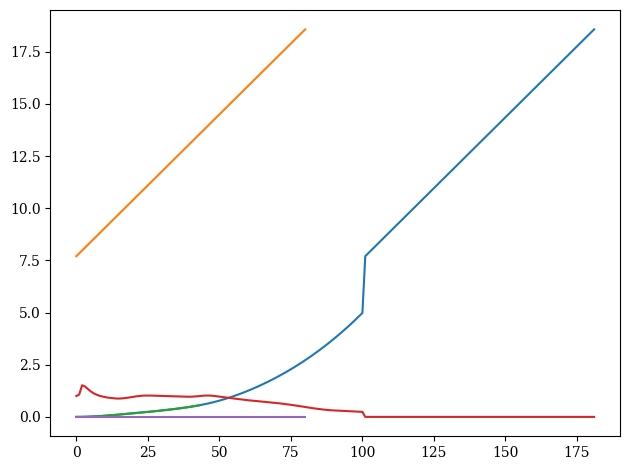

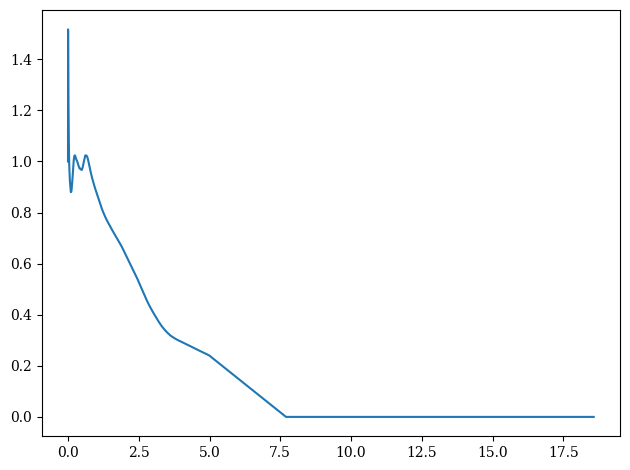

In [48]:
# Creating new input-output datapoints at large energy values that correspond to Xi of zero.
input_training_GPR3[-1]
linear_extrapolate = interp1d(np.arange(input_training_GPR3.shape[0]), np.squeeze(input_training_GPR3), fill_value="extrapolate")
x_extended = np.linspace(np.arange(input_training_GPR3.shape[0])[-1], np.arange(input_training_GPR3.shape[0])[-1] + (N-1),N)
input_constrained_GPR3_pos = linear_extrapolate(x_extended).reshape(-1,1)[int(0.20*(N-1)):]
#input_constrained_GPR3_pos2 = linear_extrapolate(x_extended).reshape(-1,1)[:int(0.5*N)]
output_constrained_GPR3_pos = np.zeros(input_constrained_GPR3_pos.shape)

# Combine the generated complete damage (Xi = 0) data with the original training data
input_training_GPR3_ext = np.vstack((input_training_GPR3, input_constrained_GPR3_pos))
output_training_GPR3_ext = np.vstack((output_training_GPR3, output_constrained_GPR3_pos))

plt.plot(input_training_GPR3_ext)
plt.plot(input_constrained_GPR3_pos)
plt.plot(input_training_GPR3_ext[:int(N_h)])
# plt.plot(np.arange(int(1.5*(N-1)),int(2*(N)-1)),input_constrained_GPR2_pos)
# plt.plot(np.arange(int(1.5*(N-1)),int(2*(N)-1)),output_constrained_GPR2_pos)
plt.plot(output_training_GPR3_ext)
plt.plot(output_constrained_GPR3_pos)
plt.show()

plt.plot(input_training_GPR3_ext,output_training_GPR3_ext)

In [49]:
# Now building two GPR models: one standard GPR model between W and Xi (with extended data incorporating zero Xi at
# large W values); and one constrained GPR model that enforces monotonicity and non-negativity constraint on Xi
# in addition to the Xi = 0 data at large W values that enforces complete failure.

# Constraint data points generation.
#x_cons = input_training_GPR3_ext[:int(N_h)] # Applying constraints on the training points.
# x_cons = np.linspace(0.6,1.25, 30).reshape(-1,1)
x_cons = np.linspace(6,15, 30).reshape(-1,1)
#x_cons = np.linspace(0,15, 100).reshape(-1,1)

# Testing data points generation (for evalutation of the trained model).
x_test = np.linspace(input_training_GPR3_ext[0],input_training_GPR3_ext[-1],500)

# GPR models' development.
# Note: We use log parameters to feed into x0, which are then shifted back to the original parameters in NLML and
# constraint functions. In this way, it is not the actual parameters but the log of parameters that are resulted by
# the optimizer. This ensures parameters always stay positive during the optimization process, important for
# numerical stability.
x0 = np.log([1.0, 1.0])  # Initial value of Kernel hyperparameters.

# === Standard GPR Optimization ===
res_std = scipy.optimize.minimize(
    neg_log_marginal_likelihood,
    x0,
    args=(input_training_GPR3_ext, output_training_GPR3_ext),
    method='L-BFGS-B',
    options={'disp': True, 'maxiter': 1000}
)
lengthscale_std, variance_std = np.exp(res_std.x)
mu_std = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, x_test, lengthscale_std, variance_std, noise)

# === Constrained GPR Optimization using a Penalized positivity NLML (for tighter, less-smooth fits) ===
#cons = {'type': 'ineq', 'fun': lambda p: derivative_constraint(p, input_training_GPR2, output_training_GPR2, input_constrained_GPR2_mono)}
cons = [
    {'type': 'ineq', 'fun': lambda p: nonnegativity_constraint(p, input_training_GPR3_ext, output_training_GPR3_ext, x_cons)},
    {'type': 'ineq', 'fun': lambda p: derivative_constraint(p, input_training_GPR3_ext, output_training_GPR3_ext, x_cons)}
]

# You can dial how strictly positivity is enforced (k) and how hard the penalty is (lam).
# Smaller k (e.g., 0.5) and larger lam (e.g., 1e4-1e6) generally give a closer fit while keeping y>=0 with high probability.
k_penalty = 0.5   # safety factor on std in the penalty (0 = hard mean>=0). Update 10192025: I ended up not using this.
lam = 1e3         # penalty strength

def penalized_obj(params, X, Y, Xc, k=k_penalty, lam=lam):
    base = neg_log_marginal_likelihood(params, X, Y)
    g_pos = nonnegativity_constraint(params, X, Y, Xc)
    g_mon = derivative_constraint(params, X, Y, Xc)
    # Quadratic penalty on violations only
    lam_pos, lam_mon = lam, lam
    penalty = lam_pos * np.sum(np.minimum(0.0, g_pos)**2) + lam_mon * np.sum(np.minimum(0.0, g_mon)**2)
    return base + penalty

# Start from the unconstrained optimum as a warm start
res_pen = scipy.optimize.minimize(
    lambda p: penalized_obj(p, input_training_GPR3_ext, output_training_GPR3_ext, x_cons, k_penalty, lam),
    res_std.x,
    method='L-BFGS-B',
    options={'maxiter': 2000}
)
lengthscale_pen, variance_pen = np.exp(res_pen.x)
mu_pen = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, x_test, lengthscale_pen, variance_pen, noise)

# An alternative method: Constrained hyperparameter optimization with SLSQP or COBYLA.
res_cons2 = scipy.optimize.minimize(
    neg_log_marginal_likelihood,
    x0,
    args=(input_training_GPR3_ext, output_training_GPR3_ext),
    constraints=cons,
    #method='SLSQP',
    method='COBYLA',
    options={'disp': False, 'maxiter': 1000} # Turn "disp" to True to see detailed convergence messages and results.
)

lengthscale_cons2, variance_cons2 = np.exp(res_cons2.x)
mu_cons2 = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, x_test, lengthscale_cons2, variance_cons2, noise)

# ALSO, COMPARE YOUR RESULTS WITH A GPR MAPPING BETWEEN INVARIANTS AND {XI*GAMMA_1; XI*GAMMA_2}. THIS IS IDENTICAL
# TO MY PREVIOUS PAPER. DID THAT AND RESULTS LOOK GREAT.

# LAST THING: USE YOGESH'S AGAROSE GEL DATA AND FIT THE DATA_DRIVEN MODEL TO IT, AND THEN PREDICT SIMPLE SHEAR
# AND PURE SHEAR RESPONSES. WHILE FITTING, USE THE LAGRANGE MULTIPLIER METHOD. WRITE THE PAPER!

C:\Users\kshit\AppData\Local\Temp\ipykernel_68376\1795133660.py:22: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res_std = scipy.optimize.minimize(


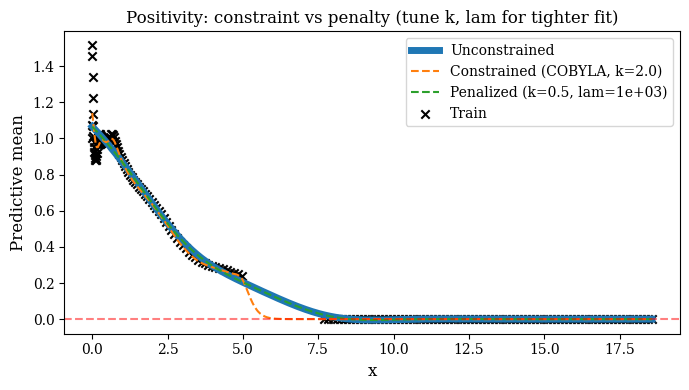

In [50]:
# Plot all three for comparison
plt.figure(figsize=(7,4))
plt.plot(x_test, mu_std, linewidth=5, label="Unconstrained")
plt.plot(x_test, mu_cons2, linestyle='--', label="Constrained (COBYLA, k=2.0)")
plt.plot(x_test, mu_pen, linestyle='--', label=f"Penalized (k={k_penalty}, lam={lam:.0e})")
#plt.plot(x, f_x, label="Ground Truth")
plt.scatter(input_training_GPR3_ext, output_training_GPR3_ext, color='k', marker='x', label='Train')
plt.axhline(0, color='r', linestyle='--', alpha=0.5)
plt.legend()
plt.xlabel("x")
plt.ylabel("Predictive mean")
plt.title("Positivity: constraint vs penalty (tune k, lam for tighter fit)")
plt.show()

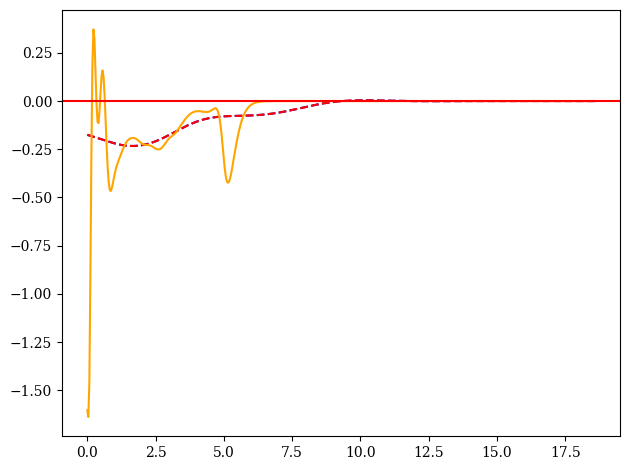

In [51]:
# Computing the derivatives of the posteriors to check monotonicity in the three GPRs.
derivative_std = np.gradient(mu_std.flatten(),x_test.flatten())
derivative_pen = np.gradient(mu_pen.flatten(),x_test.flatten())
derivative_cons2 = np.gradient(mu_cons2.flatten(),x_test.flatten())

plt.plot(x_test, derivative_std, 'b--')
plt.plot(x_test, derivative_pen, 'r--')
plt.plot(x_test, derivative_cons2, 'orange')
plt.axhline(y=0, color='r', linestyle='-')

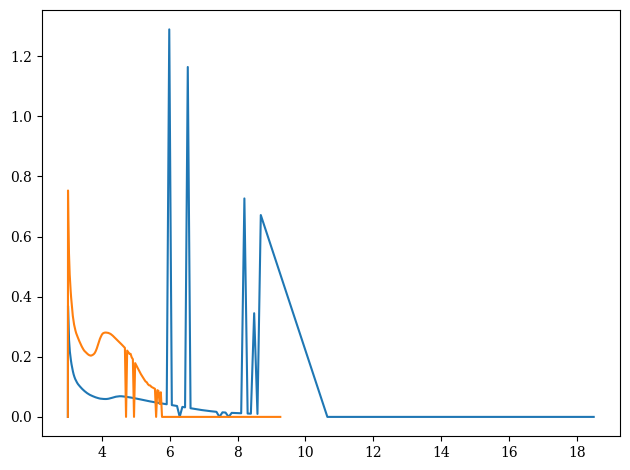

In [52]:
# Building classical undamaged GPR models (vol and iso_h) that consider the full stress strain data without
# dividing it into intact and damage components.

# The input-output datasets were generated previously: input_training_GPR_vol, input_training_GPR_iso_h,
# output_h_training_GPR_vol, and output_h_training_GPR_iso_h

# Creating new input-output datapoints at large input values that correspond to output of zero.
# linear_extrapolate_vol = interp1d(np.arange(input_training_GPR_vol.shape[0]), np.squeeze(input_training_GPR_vol[:,0]), fill_value="extrapolate")
# x_extended_vol = np.linspace(np.arange(input_training_GPR_vol.shape[0])[-1], np.arange(input_training_GPR_vol.shape[0])[-1] + (N-1),N)

linear_extrapolate_iso_h_1 = interp1d(np.arange(input_training_GPR_iso_h.shape[0]), np.squeeze(input_training_GPR_iso_h[:,0]), fill_value="extrapolate")
x_extended_iso_h_1 = np.linspace(np.arange(input_training_GPR_iso_h.shape[0])[-1], np.arange(input_training_GPR_iso_h.shape[0])[-1] + (N-1),N)

linear_extrapolate_iso_h_2 = interp1d(np.arange(input_training_GPR_iso_h.shape[0]), np.squeeze(input_training_GPR_iso_h[:,1]), fill_value="extrapolate")
x_extended_iso_h_2 = np.linspace(np.arange(input_training_GPR_iso_h.shape[0])[-1], np.arange(input_training_GPR_iso_h.shape[0])[-1] + (N-1),N)

# input_ext_vol = linear_extrapolate_vol(x_extended_vol).reshape(-1,1)[int(0.20*(N-1)):]
input_ext_iso_h_1 = linear_extrapolate_iso_h_1(x_extended_iso_h_1).reshape(-1,1)[int(0.20*(N-1)):]
input_ext_iso_h_2 = linear_extrapolate_iso_h_2(x_extended_iso_h_2).reshape(-1,1)[int(0.20*(N-1)):]

# Combine the generated complete damage (output = 0) data with the original training data
# input_training_GPR_vol_direct = np.vstack((input_training_GPR_vol, input_ext_vol))
# output_training_GPR_vol_direct = np.vstack((output_training_GPR_vol, np.zeros(input_ext_vol.shape)))

input_training_GPR_iso_h_direct = np.vstack((input_training_GPR_iso_h, np.hstack((input_ext_iso_h_1, input_ext_iso_h_2))))
output_training_GPR_iso_h_direct = np.vstack((output_training_GPR_iso_h, np.zeros(np.hstack((input_ext_iso_h_1, input_ext_iso_h_2)).shape)))

# plt.plot(input_training_GPR_vol_direct, output_training_GPR_vol_direct)
# plt.show()
plt.plot(input_training_GPR_iso_h_direct, output_training_GPR_iso_h_direct)
plt.show()

In [53]:
# alpha = 1.0e-2 * np.ones(input_training_GPR_vol_direct.shape[0])
# alpha[0] = 1.0e-5
# Krig_vol_direct = GaussianProcessRegressor(kernel=kernels[5], alpha=alpha, n_restarts_optimizer=20, normalize_y=True)
# Krig_vol_direct.fit(input_training_GPR_vol_direct,output_training_GPR_vol_direct)
# print(Krig_vol_direct.score(input_training_GPR_vol_direct,output_training_GPR_vol_direct))

Krig_iso_h_direct = GaussianProcessRegressor(kernel=kernels[5], alpha=5e-1, n_restarts_optimizer=20, normalize_y=True)
Krig_iso_h_direct.fit(input_training_GPR_iso_h_direct,output_training_GPR_iso_h_direct)
print(Krig_iso_h_direct.score(input_training_GPR_iso_h_direct,output_training_GPR_iso_h_direct))

0.5652929029864036


In [54]:
# Building a classical 6-6 GPR mapping between C and S (symmetric components)
# Now, comparing the above results with a 6-6 mapping. Here, the 6 inputs are
# the unique components of the symmetric C tensor, and the 6 outputs are the unique components of the
# symmetric 2nd P-K stress.

C11_training = [C_training[i][0,0] for i in range(len(C_training))] 
C12_training = [C_training[i][0,1] for i in range(len(C_training))]
C13_training = [C_training[i][0,2] for i in range(len(C_training))]
C22_training = [C_training[i][1,1] for i in range(len(C_training))]
C23_training = [C_training[i][1,2] for i in range(len(C_training))]
C33_training = [C_training[i][2,2] for i in range(len(C_training))]

input_train_6_6 = np.vstack((np.array(C11_training), np.array(C12_training), np.array(C13_training), np.array(C22_training),
                         np.array(C23_training), np.array(C33_training))).T

S11_training = [S_training[i][0,0] for i in range(len(S_training))] 
S12_training = [S_training[i][0,1] for i in range(len(S_training))]
S13_training = [S_training[i][0,2] for i in range(len(S_training))]
S22_training = [S_training[i][1,1] for i in range(len(S_training))]
S23_training = [S_training[i][1,2] for i in range(len(S_training))]
S33_training = [S_training[i][2,2] for i in range(len(S_training))]

output_train_6_6 = np.vstack((np.array(S11_training), np.array(S12_training), np.array(S13_training), np.array(S22_training),
                         np.array(S23_training), np.array(S33_training))).T

Krig_6_6 = GaussianProcessRegressor(kernel=kernels[5], alpha=1.0e-4, n_restarts_optimizer=10, normalize_y=True)
Krig_6_6.fit(input_train_6_6,output_train_6_6)
Krig_6_6.score(input_train_6_6,output_train_6_6)

0.9999693185136094

In [55]:
np.ceil(0.5/(F11_train[1]-F11_train[0]))

np.float64(28.0)

In [56]:
# Generating data for testing. Here, it is important to ensure that the training data remains intact inside the
# testing set, and compression data is added while ensuring the same spacing as the tension regime.

F11_comp = 2-F11_train
F11_comp_ = F11_comp[:np.where(F11_comp>0.5)[-1][-1] + 1] # Only up to a minimum of 0.5 stretch.
F11 = np.concatenate((np.flip(F11_comp_)[:-1], F11_train))

np.where(F11_comp>0.5)[-1][-1], F11_comp[np.where(F11_comp>0.5)[-1][-1]], F11_comp_, F11, np.diff(F11), F11_train

(np.int64(27),
 np.float64(0.507493),
 array([1.      , 0.981759, 0.963518, 0.945277, 0.927036, 0.908795,
        0.890554, 0.872313, 0.854072, 0.835831, 0.81759 , 0.799349,
        0.781108, 0.762867, 0.744626, 0.726385, 0.708144, 0.689903,
        0.671662, 0.653421, 0.63518 , 0.616939, 0.598698, 0.580457,
        0.562216, 0.543975, 0.525734, 0.507493]),
 array([0.507493, 0.525734, 0.543975, 0.562216, 0.580457, 0.598698,
        0.616939, 0.63518 , 0.653421, 0.671662, 0.689903, 0.708144,
        0.726385, 0.744626, 0.762867, 0.781108, 0.799349, 0.81759 ,
        0.835831, 0.854072, 0.872313, 0.890554, 0.908795, 0.927036,
        0.945277, 0.963518, 0.981759, 1.      , 1.018241, 1.036482,
        1.054723, 1.072964, 1.091205, 1.109446, 1.127687, 1.145928,
        1.164169, 1.18241 , 1.200651, 1.218892, 1.237133, 1.255374,
        1.273615, 1.291856, 1.310097, 1.328338, 1.346579, 1.36482 ,
        1.383061, 1.401302, 1.419543, 1.437784, 1.456025, 1.474266,
        1.492507, 1.510748, 

In [88]:
# Testing the accuracy of the trained GPR model.
import time

F_test = []
N = np.shape(F11)[0]
#N = 91 # 81
#F11 = np.linspace(0.5, 1.5, N)
# N = 111 # Added KU 01282026
# F11 = np.linspace(0.25, 3, N) # Added KU 01282026

N = 131 # Added KU 01292026
F11 = np.linspace(0.25, 3.5, N) # Added KU 01292026

for i in range(N):
    #F_test.append(np.array([F11[i], 0, 0, 0, 1, 0, 0, 0, 1]))
    F_test.append(np.array([F11[i], 0, 0, 0, 1/np.sqrt(F11[i]), 0, 0, 0, 1/np.sqrt(F11[i])]))
    #F_test.append(np.array([F11[i], 0, 0, 0, (F11[i]**(-nu)), 0, 0, 0, (F11[i]**(-nu))]))
    
I1_test, I2_test, _ = invariants(F_test)
C_test, C_bar_test = right_cauchy_green(F_test)
# input_test_vol = np.vstack(np.array(J_test))
input_test_iso_h = np.vstack((np.array(I1_test), np.array(I2_test))).T

# # GPR#1 model
# output_h_test_vol = Krig_1_vol.predict(input_test_vol)

# GPR#2 model
output_h_test_iso_h = Krig_2_iso_h.predict(input_test_iso_h)

S_h_test = []
for i in range(len(F_test)):
    G1_temp = np.linalg.inv(C_test[i])
    G2_temp = ref_deviatoric(np.eye(3), C_test[i])
    G3_temp = ref_deviatoric(C_bar_test[i], C_test[i])
    
    S_h_test.append((output_h_test_iso_h[i,0] * (G2_temp - (G2_temp[1][1]/G1_temp[1][1]) * G1_temp)) +
                        (output_h_test_iso_h[i,1] * (G3_temp - (G3_temp[1][1]/G1_temp[1][1]) * G1_temp)))
    
    # S_h_test_vol = output_h_test_vol[i] * np.linalg.inv(C_test[i])
    # S_h_test_iso_h = J_test[i] ** (-2/3) * (output_h_test_iso_h[i,0] * ref_deviatoric(np.eye(3), C_test[i]) + output_h_test_iso_h[i,1] * ref_deviatoric(C_bar_test[i], C_test[i]))
    # S_h_test.append(S_h_test_vol + S_h_test_iso_h)

S11_h_test, S22_h_test = [], []
for i in range(len(F_test)):
    S11_h_test.append(S_h_test[i][0,0])
    S22_h_test.append(S_h_test[i][1,1])
    
# Compute the strain energy density. This needs to be done separately for tension and compression.
W_h_ten_temp = strain_energy_density(C_test[int(np.where(F11==1.0)[0][0]):], S_h_test[int(np.where(F11==1.0)[0][0]):])
W_h_comp_temp = strain_energy_density(list(reversed(C_test[:int(np.where(F11==1.0)[0][0])+1])), list(reversed(S_h_test[:int(np.where(F11==1.0)[0][0])+1])))
W_h_test = list(reversed(W_h_comp_temp)) + W_h_ten_temp[1:]

In [89]:
len(W_h_test), F11[int(np.where(F11==1.0)[0][0])], W_h_test[int(np.where(F11==1.0)[0][0])], I1_test[int(np.where(F11==1.0)[0][0])], I2_test[int(np.where(F11==1.0)[0][0])], int(np.where(F11==1.0)[0][0])

(131, np.float64(1.0), 0, np.float64(3.0), np.float64(3.0), 30)

In [90]:
# GPR#3 model with monotonicity and non-negativity constraints.
input_test_GPR3 = np.array(W_h_test).reshape(-1,1)

output_test = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, input_test_GPR3, lengthscale_pen, variance_pen, noise)
#output_test = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, input_test_GPR3, lengthscale_cons2, variance_cons2, noise)

S_test = []
for i in range(len(F_test)):
    S_test.append(output_test[i] * S_h_test[i])
    
S11_test, S22_test = [], []
for i in range(len(F_test)):
    S11_test.append(S_test[i][0,0])
    S22_test.append(S_test[i][1,1])
    
# GPR#3 model with no constraint (standard GPR).
output_test_stdGPR = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, input_test_GPR3, lengthscale_std, variance_std, noise)

S_test_stdGPR = []
for i in range(len(F_test)):
    S_test_stdGPR.append(output_test_stdGPR[i] * S_h_test[i])
    
S11_test_stdGPR, S22_test_stdGPR = [], []
for i in range(len(F_test)):
    S11_test_stdGPR.append(S_test_stdGPR[i][0,0])
    S22_test_stdGPR.append(S_test_stdGPR[i][1,1])

In [91]:
# Classical direct GPR.

# output_test_GPR_vol_direct = Krig_vol_direct.predict(input_test_vol)
output_test_GPR_iso_h_direct = Krig_iso_h_direct.predict(input_test_iso_h)

S_test_GPR_direct = []
for i in range(len(F_test)):
    G1_temp = np.linalg.inv(C_test[i])
    G2_temp = ref_deviatoric(np.eye(3), C_test[i])
    G3_temp = ref_deviatoric(C_bar_test[i], C_test[i])
    
    S_test_GPR_direct.append((output_test_GPR_iso_h_direct[i,0] * (G2_temp - (G2_temp[1][1]/G1_temp[1][1]) * G1_temp)) +
                        (output_test_GPR_iso_h_direct[i,1] * (G3_temp - (G3_temp[1][1]/G1_temp[1][1]) * G1_temp)))
    
    # S_test_GPR_vol_direct = output_test_GPR_vol_direct[i] * np.linalg.inv(C_test[i])
    # S_test_GPR_iso_h_direct = J_test[i] ** (-2/3) * (output_test_GPR_iso_h_direct[i,0] * ref_deviatoric(np.eye(3), C_test[i]) + output_test_GPR_iso_h_direct[i,1] * ref_deviatoric(C_bar_test[i], C_test[i]))
    # S_test_GPR_direct.append(S_test_GPR_vol_direct + S_test_GPR_iso_h_direct)

S11_test_GPR_direct, S22_test_GPR_direct = [], []
for i in range(len(F_test)):
    S11_test_GPR_direct.append(S_test_GPR_direct[i][0,0])
    S22_test_GPR_direct.append(S_test_GPR_direct[i][1,1])

In [92]:
# Compute total strain energy density from the fully trained model. This needs to be done separately for tension and compression.
W_h_ten_temp = strain_energy_density(C_test[int(np.where(F11==1.0)[0][0]):], S_h_test[int(np.where(F11==1.0)[0][0]):])
W_h_comp_temp = strain_energy_density(list(reversed(C_test[:int(np.where(F11==1.0)[0][0])+1])), list(reversed(S_h_test[:int(np.where(F11==1.0)[0][0])+1])))

W_ten_test = strain_energy_density(C_test[int(np.where(F11==1.0)[0][0]):], S_test[int(np.where(F11==1.0)[0][0]):])
W_comp_test = strain_energy_density(list(reversed(C_test[:int(np.where(F11==1.0)[0][0])+1])), list(reversed(S_test[:int(np.where(F11==1.0)[0][0])+1])))
W_test = list(reversed(W_comp_test)) + W_ten_test[1:]

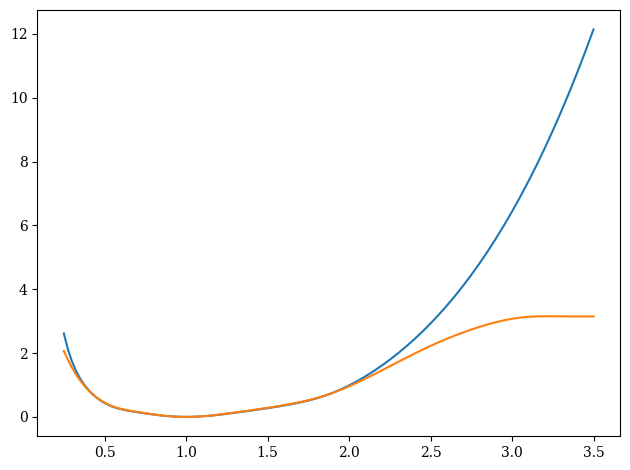

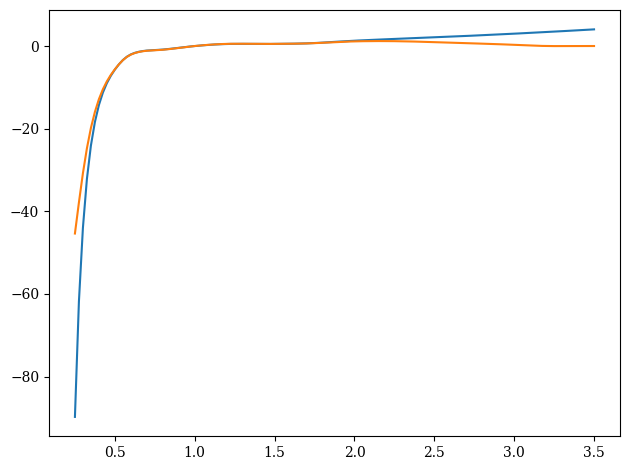

In [93]:
plt.plot(F11,W_h_test)
plt.plot(F11, W_test)
plt.show()
W_h_test[int(np.where(F11==1.0)[0][0])]
#W_h_test

plt.plot(F11,S11_h_test)
plt.plot(F11, S11_test)
plt.show()

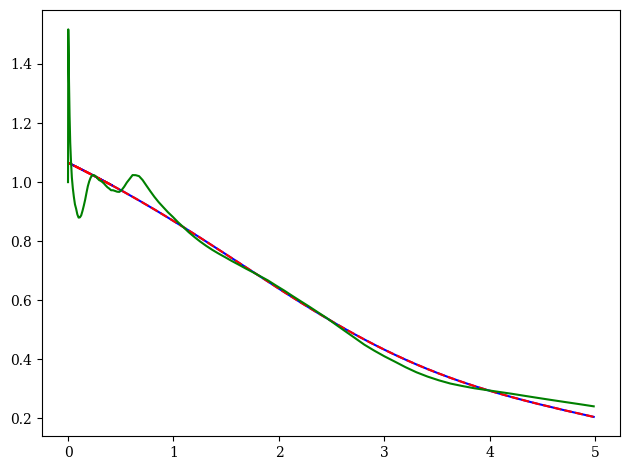

In [62]:
plt.plot(W_h_test, output_test, 'b')
plt.plot(W_h_test, output_test_stdGPR, 'r--')
plt.plot(input_training_GPR3, output_training_GPR3, 'g')
# NOTE: I NEED TO APPLY TWO CONSTRAINTS ON DAMAGE: NON-NEGATIVITY, AND MONOTONICITY (DOWNWARD).

In [63]:
# Classical 6-6 mapping model
C11_test = [C_test[i][0,0] for i in range(len(C_test))] 
C12_test = [C_test[i][0,1] for i in range(len(C_test))]
C13_test = [C_test[i][0,2] for i in range(len(C_test))]
C22_test = [C_test[i][1,1] for i in range(len(C_test))]
C23_test = [C_test[i][1,2] for i in range(len(C_test))]
C33_test = [C_test[i][2,2] for i in range(len(C_test))]

input_test_6_6 = np.vstack((np.array(C11_test), np.array(C12_test), np.array(C13_test), np.array(C22_test),
                         np.array(C23_test), np.array(C33_test))).T
output_test_6_6 = Krig_6_6.predict(input_test_6_6)

S_test_6_6 = []
for i in range(len(F_test)):
    S_test_6_6.append(np.array([[output_test_6_6[i][0], output_test_6_6[i][1], output_test_6_6[i][2]],
                           [output_test_6_6[i][1], output_test_6_6[i][3], output_test_6_6[i][4]],
                           [output_test_6_6[i][2], output_test_6_6[i][4], output_test_6_6[i][5]]]))

S11_test_6_6, S22_test_6_6 = [], []
for i in range(len(F_test)):
    S11_test_6_6.append(S_test_6_6[i][0,0])
    S22_test_6_6.append(S_test_6_6[i][1,1])

In [64]:
# Extended SM+MR+Damage Model (ground truth)

# S_ground_truth = []
# W_h_ground_truth = []
# for i in range(len(F_test)):
#     S_h_MR_temp = 2 * (input_test_vol[i] ** (-2/3)) * ((A10 + (input_test_iso_h[i,0] * A01)) * ref_deviatoric(np.eye(3), C_test[i]) - A01 * ref_deviatoric(C_bar_test[i], C_test[i]))
#     S_h_SM_temp = (kappa/2) * (input_test_vol[i]**2 - 1) * np.linalg.inv(C_test[i])
#     S_h_temp = S_h_MR_temp + S_h_SM_temp
    
#     W_h_MR_temp = A10 * (input_test_iso_h[i,0] - 3) + A01 * (input_test_iso_h[i,1] - 3)
#     W_h_SM_temp = (kappa/2) * (((input_test_vol[i]**2 - 1)/2) - np.log(input_test_vol[i]))
#     W_h_ground_truth.append(W_h_MR_temp + W_h_SM_temp)
#     # S_training_vol.append(np.exp(-((W_h[i]/phi)**m)) * S_h_SM)
#     # S_training_iso_h.append(np.exp(-((W_h[i]/phi)**m)) * S_h_MR)
#     S_ground_truth.append(np.exp(-((W_h_ground_truth[i]/phi)**m)) * S_h_temp)

# S11_ground_truth, S22_ground_truth = [], []
# for i in range(len(F_test)):
#     S11_ground_truth.append(S_ground_truth[i][0,0])
#     S22_ground_truth.append(S_ground_truth[i][1,1])
    
# Predictions of the 1-term volumetric NH + 2-term Yeoh + 1 term old Volokh model.
S_YH = []
W_YH = []
for i in range(len(F_test)):
    W_YH.append(((C1_YH * (input_test_iso_h[i,0] - 3)) + (C2_YH * ((input_test_iso_h[i,0] - 3)**2))))

    G1_temp = np.linalg.inv(C_test[i])
    G2_temp = ref_deviatoric(np.eye(3), C_test[i])
    
    # S_YH.append(np.exp(-W_YH[i]/phi1) * ((K_NH*input_test_vol[i]*(input_test_vol[i] - 1)* np.linalg.inv(C_test[i])) +
    #     ((input_test_vol[i]**(-2/3)) * (2*C1_YH + 4*C2_YH*(input_test_iso_h[i,0] - 3))
    #            * ref_deviatoric(np.eye(3), C_test[i]))))

    S_YH.append(np.exp(-W_YH[i]/phi1) * ((2*C1_YH + 4*C2_YH*(input_test_iso_h[i,0] - 3)) * 
                                       (G2_temp - (G2_temp[1][1]/G1_temp[1][1]) * G1_temp)))

S11_YH, S22_YH = [], []
for i in range(len(F_test)):
    S11_YH.append(S_YH[i][0,0])
    S22_YH.append(S_YH[i][1,1])

In [65]:
C_test[38], S_YH[38]#, S_ground_truth[38]

(array([[1.44156282, 0.        , 0.        ],
        [0.        , 0.8328815 , 0.        ],
        [0.        , 0.        , 0.8328815 ]]),
 array([[2.64248467e-01, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.73702596e-17, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 1.73702596e-17]]))

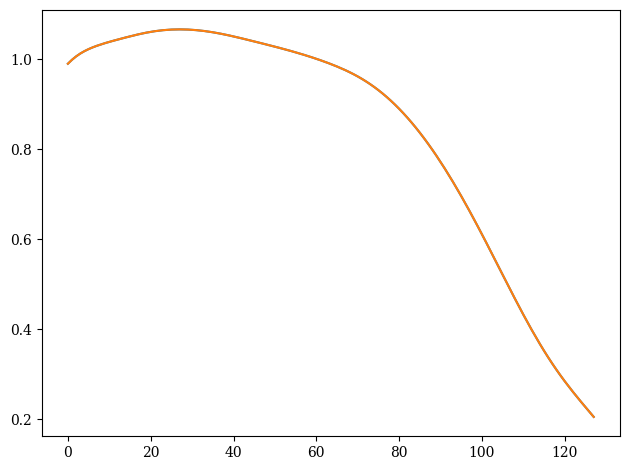

In [66]:
plt.plot(output_test)
plt.plot(output_test_stdGPR)

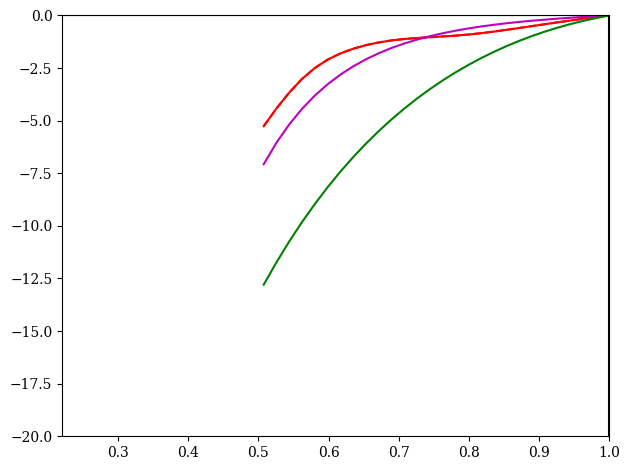

In [67]:
plt.plot(F11,S11_test, color = 'r')
plt.plot(F11,S11_test_stdGPR, color = 'r', linestyle='--')
#plt.plot(F11,S11_test_undmgGPR, color = 'k', linestyle='--')
#plt.plot(F11,S11_ground_truth, color = 'b')
plt.plot(F11,S11_YH, color = 'm')
plt.plot(F11,S11_test_6_6, color = 'g')

plt.plot(F11_train, S11_training,'m--')

plt.axhline(y=0, color='k', linestyle='-')
plt.axvline(x=1, color='k', linestyle='-')
plt.ylim((-20, 0))
plt.xlim((0.22, 1))

#plt.savefig("Testing.svg")
plt.show()

# plt.plot(F11,S22_test, color = 'r')
# plt.plot(F11,S22_test_stdGPR, color = 'r', linestyle='--')
# #plt.plot(F11,S11_test_undmgGPR, color = 'k', linestyle='--')
# #plt.plot(F11,S22_ground_truth, color = 'b')
# plt.plot(F11,S22_YH, color = 'm')
# plt.plot(F11,S22_test_6_6, color = 'g')

# plt.plot(F11_train, S22_training,'m--')

# plt.axhline(y=0, color='k', linestyle='-')
# plt.axvline(x=1, color='k', linestyle='-')
# plt.show()

In [68]:
# Testing the accuracy of the trained GPR model in the shear deformation mode.

F_test_sh = []
# M = 26
M = 51
#F12 = np.linspace(0, 0.8, M)
F12 = np.linspace(0, 5, M)
for i in range(M):
    #F_test.append(np.array([F11[i], 0, 0, 0, 1, 0, 0, 0, 1]))
    F_test_sh.append(np.array([1, F12[i], 0, 0, 1, 0, 0, 0, 1]))
    
I1_test_sh, I2_test_sh, _ = invariants(F_test_sh)
C_test_sh, C_bar_test_sh = right_cauchy_green(F_test_sh)
# input_test_sh_vol = np.vstack(np.array(J_test_sh))
input_test_sh_iso_h = np.vstack((np.array(I1_test_sh), np.array(I2_test_sh))).T

# # GPR#1 model
# output_h_test_sh_vol = Krig_1_vol.predict(input_test_sh_vol)

# GPR#2 model
output_h_test_sh_iso_h = Krig_2_iso_h.predict(input_test_sh_iso_h)

S_h_test_sh = []
for i in range(len(F_test_sh)):
    G1_temp = np.linalg.inv(C_test_sh[i])
    G2_temp = ref_deviatoric(np.eye(3), C_test_sh[i])
    G3_temp = ref_deviatoric(C_bar_test_sh[i], C_test_sh[i])
    
    S_h_test_sh.append((output_h_test_sh_iso_h[i,0] * (G2_temp - (G2_temp[1][1]/G1_temp[1][1]) * G1_temp)) +
                        (output_h_test_sh_iso_h[i,1] * (G3_temp - (G3_temp[1][1]/G1_temp[1][1]) * G1_temp)))
    
    # S_h_test_sh_vol = output_h_test_sh_vol[i] * np.linalg.inv(C_test_sh[i])
    # S_h_test_sh_iso_h = J_test_sh[i] ** (-2/3) * (output_h_test_sh_iso_h[i,0] * ref_deviatoric(np.eye(3), C_test_sh[i]) + output_h_test_sh_iso_h[i,1] * ref_deviatoric(C_bar_test_sh[i], C_test_sh[i]))
    # S_h_test_sh.append(S_h_test_sh_vol + S_h_test_sh_iso_h)

S12_h_test_sh = []
for i in range(len(F_test_sh)):
    S12_h_test_sh.append(S_h_test_sh[i][0,1])
    
# Compute the strain energy density.
W_h_test_sh = strain_energy_density(C_test_sh, S_h_test_sh)

In [69]:
# GPR#3 model with monotonicity and non-negativity constraints.
input_test_GPR3_sh = np.array(W_h_test_sh).reshape(-1,1)

output_test_sh = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, input_test_GPR3_sh, lengthscale_pen, variance_pen, noise)

S_test_sh = []
for i in range(len(F_test_sh)):
    S_test_sh.append(output_test_sh[i] * S_h_test_sh[i])
    
S12_test_sh = []
for i in range(len(F_test_sh)):
    S12_test_sh.append(S_test_sh[i][0,1])
    
# GPR#3 model with no constraint (standard GPR).
output_test_stdGPR_sh = predict_mu(input_training_GPR3_ext, output_training_GPR3_ext, input_test_GPR3_sh, lengthscale_std, variance_std, noise)

S_test_stdGPR_sh = []
for i in range(len(F_test_sh)):
    S_test_stdGPR_sh.append(output_test_stdGPR_sh[i] * S_h_test_sh[i])
    
S12_test_stdGPR_sh = []
for i in range(len(F_test_sh)):
    S12_test_stdGPR_sh.append(S_test_stdGPR_sh[i][0,1])

In [70]:
# Classical 6-6 mapping model
C11_test_sh = [C_test_sh[i][0,0] for i in range(len(C_test_sh))] 
C12_test_sh = [C_test_sh[i][0,1] for i in range(len(C_test_sh))]
C13_test_sh = [C_test_sh[i][0,2] for i in range(len(C_test_sh))]
C22_test_sh = [C_test_sh[i][1,1] for i in range(len(C_test_sh))]
C23_test_sh = [C_test_sh[i][1,2] for i in range(len(C_test_sh))]
C33_test_sh = [C_test_sh[i][2,2] for i in range(len(C_test_sh))]

input_test_6_6_sh = np.vstack((np.array(C11_test_sh), np.array(C12_test_sh), np.array(C13_test_sh), np.array(C22_test_sh),
                         np.array(C23_test_sh), np.array(C33_test_sh))).T
output_test_6_6_sh = Krig_6_6.predict(input_test_6_6_sh)

S_test_6_6_sh = []
for i in range(len(F_test_sh)):
    S_test_6_6_sh.append(np.array([[output_test_6_6_sh[i][0], output_test_6_6_sh[i][1], output_test_6_6_sh[i][2]],
                           [output_test_6_6_sh[i][1], output_test_6_6_sh[i][3], output_test_6_6_sh[i][4]],
                           [output_test_6_6_sh[i][2], output_test_6_6_sh[i][4], output_test_6_6_sh[i][5]]]))

S12_test_6_6_sh = []
for i in range(len(F_test_sh)):
    S12_test_6_6_sh.append(S_test_6_6_sh[i][0,1])
    

In [71]:
# Extended SM+MR+Damage Model (ground truth)

# S_ground_truth_sh = []
# W_h_ground_truth_sh = []
# for i in range(len(F_test_sh)):
#     S_h_MR_temp_sh = 2 * (input_test_sh_vol[i] ** (-2/3)) * ((A10 + (input_test_sh_iso_h[i,0] * A01)) * ref_deviatoric(np.eye(3), C_test_sh[i]) - A01 * ref_deviatoric(C_bar_test_sh[i], C_test_sh[i]))
#     S_h_SM_temp_sh = (kappa/2) * (input_test_sh_vol[i]**2 - 1) * np.linalg.inv(C_test_sh[i])
#     S_h_temp_sh = S_h_MR_temp_sh + S_h_SM_temp_sh
    
#     W_h_MR_temp_sh = A10 * (input_test_sh_iso_h[i,0] - 3) + A01 * (input_test_sh_iso_h[i,1] - 3)
#     W_h_SM_temp_sh = (kappa/2) * (((input_test_sh_vol[i]**2 - 1)/2) - np.log(input_test_sh_vol[i]))
#     W_h_ground_truth_sh.append(W_h_MR_temp_sh + W_h_SM_temp_sh)
#     S_ground_truth_sh.append(np.exp(-((W_h_ground_truth_sh[i]/phi)**m)) * S_h_temp_sh)

# S12_ground_truth_sh = []
# for i in range(len(F_test_sh)):
#     S12_ground_truth_sh.append(S_ground_truth_sh[i][0,1])


# Predictions of the 1-term volumetric NH + 2-term Yeoh + 1 term old Volokh model.
S_YH_sh = []
W_YH_sh = []
for i in range(len(F_test_sh)):
    W_YH_sh.append(((C1_YH * (input_test_sh_iso_h[i,0] - 3)) + (C2_YH * ((input_test_sh_iso_h[i,0] - 3)**2))))

    G1_temp = np.linalg.inv(C_test_sh[i])
    G2_temp = ref_deviatoric(np.eye(3), C_test_sh[i])

    S_YH_sh.append(np.exp(-W_YH_sh[i]/phi1) * ((2*C1_YH + 4*C2_YH*(input_test_sh_iso_h[i,0] - 3)) * 
                                       (G2_temp - (G2_temp[1][1]/G1_temp[1][1]) * G1_temp))) 
    
    # W_YH_sh.append(((K_NH/2) * (input_test_sh_vol[i] - 1)**2) + (C1_YH * (input_test_sh_iso_h[i,0] - 3)) + (C2_YH * ((input_test_sh_iso_h[i,0] - 3)**2)))
    # S_YH_sh.append(np.exp(-W_YH_sh[i]/phi1) * ((K_NH*input_test_sh_vol[i]*(input_test_sh_vol[i] - 1)* np.linalg.inv(C_test_sh[i])) +
    #     ((input_test_sh_vol[i]**(-2/3)) * (2*C1_YH + 4*C2_YH*(input_test_sh_iso_h[i,0] - 3))
    #            * ref_deviatoric(np.eye(3), C_test_sh[i]))))

S12_YH_sh = []
for i in range(len(F_test_sh)):
    S12_YH_sh.append(S_YH_sh[i][0,1])

In [72]:
len(S11_test[int(np.where(F11==1.0)[0][0]):]), len(S_training), len(S11_training)

(101, 101, 101)

In [73]:
# Computing the fitting error. Only the 11-component is considered as all others are zero.
S11_test_tension = S11_test[int(np.where(F11==1.0)[0][0]):]

err_test_overall = []
for i in range(len(S_training)):
    S_diff = S11_test_tension[i] - S11_training[i]
    # Avoiding division by very small values by adding a max condition in the denominator.
    err_test_overall.append(np.linalg.norm(S_diff) / np.max((0.01*np.max(S11_training), S11_training[i])))

mean_err_trainregime = np.nanmean(np.array(err_test_overall)) # mean error in the training regime.
max_err_trainregime = np.nanmax(np.array(err_test_overall))


# Computing error metric for the YH model.
S11_YH_tension = S11_YH[int(np.where(F11==1.0)[0][0]):]
err_YH_overall = []
for i in range(len(S_training)):
    S_diff = S11_YH_tension[i] - S11_training[i]
    # Avoiding division by very small values by adding a max condition in the denominator.
    err_YH_overall.append(np.linalg.norm(S_diff) / np.max((0.01*np.max(S11_training), S11_training[i])))

mean_err_trainregime_YH = np.nanmean(np.array(err_YH_overall)) # mean error in the training regime.

# Computing error metric for the 6-6 classical mapping model.
S11_test_6_6_tension = S11_test_6_6[int(np.where(F11==1.0)[0][0]):]
err_test_6_6_overall = []
for i in range(len(S_training)):
    S_diff = S11_test_6_6_tension[i] - S11_training[i]
    # Avoiding division by very small values by adding a max condition in the denominator.
    err_test_6_6_overall.append(np.linalg.norm(S_diff) / np.max((0.01*np.max(S11_training), S11_training[i])))
    
mean_err_trainregime_6_6 = np.nanmean(np.array(err_test_6_6_overall)) # mean error in the training regime of J = 0.75 to 1.

print('Mean relative errors in the training regime:', mean_err_trainregime, mean_err_trainregime_YH, mean_err_trainregime_6_6)
print('Max relative error of the GPR surrogate model:', max_err_trainregime)

Mean relative errors in the training regime: 0.05107073613992312 0.16121539057992446 0.00954893848660387
Max relative error of the GPR surrogate model: 0.29766143398211276


In [ ]:
# # Combining the uniaxial and shear testing data.

# S_test_overall = S_test + S_test_sh
# S_test_stdGPR_overall = S_test_stdGPR + S_test_stdGPR_sh
# S_test_6_6_overall = S_test_6_6 + S_test_6_6_sh
# S_ground_truth_overall = S_ground_truth + S_ground_truth_sh
# S_YH_overall = S_YH + S_YH_sh

In [ ]:
# len(S_test), len(S_test_sh), len(S_test_overall), S_test[80]

In [ ]:
# # Testing the accuracy of the trained GPR model by computing error metrics and comparing with errors from YH model and 6-6 mapping GPR model.
# # Computing error metric for the GPR surrogate model.
# norm_ground_truth = []
# for i in range(len(S_test_overall)):
#     norm_ground_truth.append(np.linalg.norm(S_ground_truth_overall[i]))
# max_norm_ground_truth = np.max(norm_ground_truth)

# err_test_overall = []
# for i in range(len(S_test_overall)):
#     S_diff = S_test_overall[i] - S_ground_truth_overall[i]
#     # err_test_overall.append(np.linalg.norm(S_diff) / np.linalg.norm(S_ground_truth_overall[i]))
#     # Avoiding division by very small values by adding a max condition in the denominator.
#     err_test_overall.append(np.linalg.norm(S_diff) / np.max((0.01*max_norm_ground_truth, norm_ground_truth[i])))

# err_test_overall_ = err_test_overall.copy()
# if inf in err_test_overall_:
#     err_test_overall_.remove(inf) # After I added the 0.01*max() term in the denominator, there can't be inf in this dataset, so err_test_overall = err_test_overall_

# mean_err_trainregime = np.nanmean(np.array(err_test_overall_)[40:81]) # mean error in the training regime of F11 = 1 to 1.5.
# max_err_trainregime = np.nanmax(np.array(err_test_overall_)[40:81])
# mean_err_test = np.nanmean(np.array(err_test_overall_))# Overall mean error

# # Computing error metric for the YH model.
# err_YH_overall = []
# for i in range(len(S_test_overall)):
#     S_diff = S_YH_overall[i] - S_ground_truth_overall[i]
#     # err_YH_overall.append(np.linalg.norm(S_diff) / np.linalg.norm(S_ground_truth_overall[i]))
#     err_YH_overall.append(np.linalg.norm(S_diff) / np.max((0.01*max_norm_ground_truth, norm_ground_truth[i])))

# err_YH_overall_ = err_YH_overall.copy()
# if inf in err_YH_overall_:
#     err_YH_overall_.remove(inf)

# mean_err_trainregime_YH = np.nanmean(np.array(err_YH_overall_)[40:81]) # mean error in the training regime of F11 = 1 to 1.5.
# mean_err_YH = np.nanmean(np.array(err_YH_overall_))# Overall mean error

# # Computing error metric for the 6-6 classical mapping model.
# err_test_6_6_overall = []
# for i in range(len(S_test_6_6_overall)):
#     S_diff = S_test_6_6_overall[i] - S_ground_truth_overall[i]
#     # err_test_6_6_overall.append(np.linalg.norm(S_diff) / np.linalg.norm(S_ground_truth_overall[i]))
#     err_test_6_6_overall.append(np.linalg.norm(S_diff) / np.max((0.01*max_norm_ground_truth, norm_ground_truth[i])))


# err_test_6_6_overall_ = err_test_6_6_overall.copy()
# if inf in err_test_6_6_overall_:
#     # err_test_6_6_overall_.remove(inf)
#     err_test_6_6_overall_[40] = nan
#     err_test_6_6_overall_[81] = nan
# # if inf in err_test_6_6_overall_:
# #     err_test_6_6_overall_.remove(inf)
# mean_err_trainregime_6_6 = np.nanmean(np.array(err_test_6_6_overall_)[40:81]) # mean error in the training regime of J = 0.75 to 1.
# mean_err_test_6_6 = np.nanmean(np.array(err_test_6_6_overall_))# Overall mean error

# print('Mean relative errors in the training regime:', mean_err_trainregime, mean_err_trainregime_YH, mean_err_trainregime_6_6)
# print('Max relative error of the GPR surrogate model:', max_err_trainregime)
# print('Mean relative errors in the testing regime:', mean_err_test, mean_err_YH, mean_err_test_6_6)

In [ ]:
# np.nanmean(np.array(err_test_overall_)[:81]), np.nanmean(np.array(err_YH_overall_)[:81]), np.nanmean(np.array(err_test_6_6_overall_)[:81])

In [ ]:
# np.nanmax(np.array(err_YH_overall_)[81:])

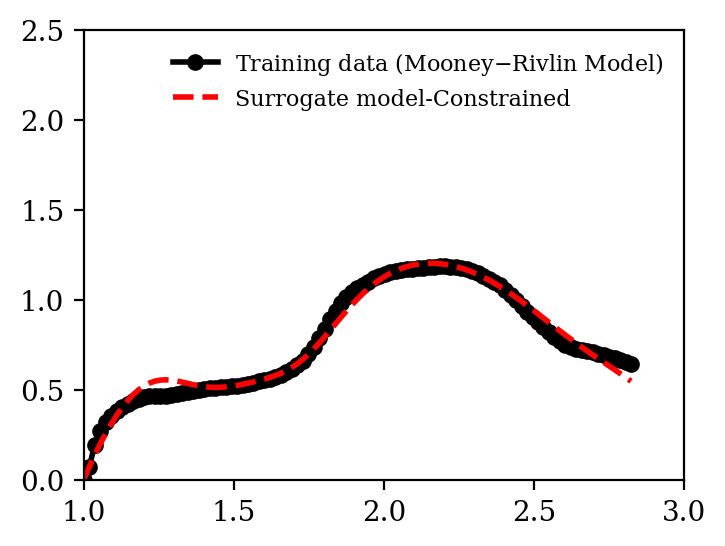

In [81]:
# Plotting the fitted stress by the data-driven model.
# Plot 1a. Training data and Fitted Response.
plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)
#ax = fig.add_subplot(1, 1, 1)

#plt.xlim([1, 1.27])
#plt.ylim([-1, 1])

ax.plot(F11_train, S11_training, c = 'k', marker = 'o', markersize = '5', linewidth = 2, label = 'Training data (Mooney$-$Rivlin Model)')
ax.plot(F11[int(np.where(F11==1.0)[0][0]):], np.array(S11_test)[int(np.where(F11==1.0)[0][0]):], c = 'r', linestyle = '--', linewidth = 2, label = 'Surrogate model-Constrained')
#ax.plot(F11[40:], np.array(S11_test_stdGPR)[40:], c = 'm', linestyle = '--', linewidth = 2, label = 'Surrogate model-Unconstrained')
#ax.plot(F11_train, S22_training, c = 'k', marker = 'o', markersize = '5', linewidth = 2)
#ax.plot(F11[int(np.where(F11==1.0)[0][0]):], np.array(S22_test)[int(np.where(F11==1.0)[0][0]):], c = 'r', linestyle = '--', linewidth = 2)
#ax.plot(F11[40:], np.array(S22_test_stdGPR)[40:], c = 'm', linestyle = '--', linewidth = 2, label = 'Surrogate model-Unconstrained')
plt.xlim([1, 3])
plt.ylim((0, 2.5))

#ax.set_xlabel('$\lambda$')
#ax.set_ylabel('$S_{h,\mathrm{iso, 11}}$, $S_{h,\mathrm{iso, 22}}$')
ax.legend(frameon=False, prop={'size': 8})
plt.savefig("Hyperelastic_training_fitting_WM-p.svg")
plt.show()

<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
C:\Users\kshit\AppData\Local\Temp\ipykernel_68376\500338787.py:18: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('$\lambda$')


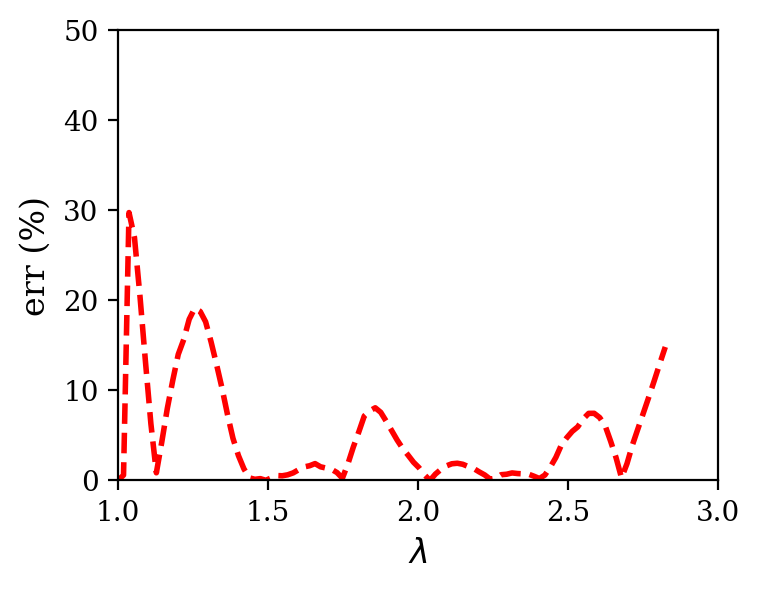

In [80]:
# Plot 1b: Relative error metric versus (lambda stretch) in the fitting regime

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

#ax = fig.add_subplot(1, 1, 1)
plt.xlim([1, 3])
plt.ylim([0, 50])

ax.plot(F11_train, 100 * np.array(err_test_overall), c = 'r', linestyle = '--', linewidth = 2)
ax.set_xlabel('$\lambda$')
ax.set_ylabel('err (%)')
plt.savefig("Hyperelastic_training_fitting_error_WM-p.svg",bbox_inches='tight')
plt.show()

C:\Users\kshit\AppData\Local\Temp\ipykernel_68376\3725763311.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, prop={'size': 8})


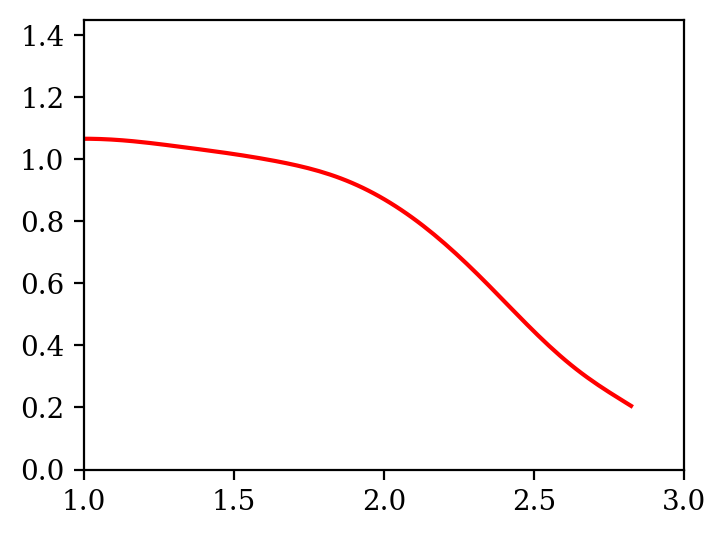

1.0659947150128812


In [79]:
# Plot 4b: Predicted stress-reduction factor (input of Stage II) vs stretch.
plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

ax.plot(F11, output_test, c = 'r', linestyle = '-')

plt.ylim((0, 1.45))
plt.xlim((1, 3))

#ax.set_xlabel('$\lambda$')
#ax.set_ylabel('$S_{h,\mathrm{iso, 11}}$, $S_{h,\mathrm{iso, 22}}$')
ax.legend(frameon=False, prop={'size': 8})
plt.savefig("Xi_vs_stretch_WM-p.svg")
plt.show()
print(np.max(output_test))

C:\Users\kshit\AppData\Local\Temp\ipykernel_68376\1843042161.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, prop={'size': 8})


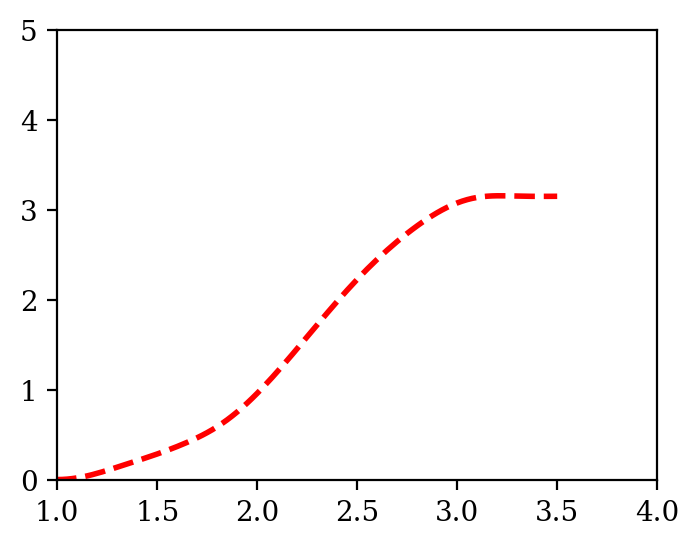

In [94]:
# Plot 4c: Strain energy density predictions of stage I vs stage II.
plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

#ax.plot(F11_train, W_h, c = 'k', marker = 'o', markersize = '5', linewidth = 2, label = 'Ground truth') #marker = 'o', markersize = '5',
#ax.plot(F11[40:], np.array(W_h_test)[40:], color = 'r', linestyle = ':', linewidth = 2, label = 'Stage I prediction')
ax.plot(F11, np.array(W_test), c = 'r', linestyle = '--', linewidth = 2)#, label = 'Total strain energy density prediction (Stages I and II)')

#plt.ylim((0, 1.6))
plt.ylim((0, 5))
plt.xlim((1, 4))

#ax.set_xlabel('$\lambda$')
#ax.set_ylabel('$S_{h,\mathrm{iso, 11}}$, $S_{h,\mathrm{iso, 22}}$')
ax.legend(frameon=False, prop={'size': 8})
plt.savefig("Total_strain_energy_density_WM-p.svg")
plt.show()

In [95]:
#F11.shape, x_test.shape, F11_test.shape
np.array(W_test)[-1]

np.float64(3.147462056944038)

In [ ]:
# Plot 7a: Predicted stress-reduction factor as a function of W (M_dam prediction): constrained vs unconstrained GPR.
plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

# ax.plot(F11, output_test, c = 'r', linestyle = '-')
# ax.plot(F11, output_test_stdGPR, c = 'm', linestyle = ':')

#ax.plot(x_test, mu_cons2, label="Constrained (COBYLA, k=2.0)")
ax.plot(input_training_GPR3_ext[np.where(input_training_GPR3_ext<=0.8)], output_training_GPR3_ext[np.where(input_training_GPR3_ext<=0.8)], color='k',  markersize = '5', linewidth = 0, marker='o', label='Train')
ax.plot(input_training_GPR3_ext[np.where(input_training_GPR3_ext>0.8)], output_training_GPR3_ext[np.where(input_training_GPR3_ext>0.8)], color='k',  markersize = '5', linewidth = 0, marker='x', label='Train')
ax.plot(x_cons, np.zeros(np.shape(x_cons))-0.2, color='c', marker='^',  markersize = '5', linewidth = 0, label='Constraint inputs (Mono and NN)')
#ax.axhline(0, color='r', linewidth = 2, linestyle='--', alpha=0.5)
ax.plot(x_test, mu_pen, c = 'r', linewidth = 2, linestyle = '-', label=f"Penalized (k={k_penalty}, lam={lam:.0e})")
ax.plot(x_test, mu_std, c = 'm', linewidth = 2, linestyle = ':', label="Unconstrained")

#marker = 'o', markersize = '5', c = 'k', linewidth = 2
plt.ylim((-0.2, 1.45))
#plt.xlim((0, 3))

#ax.set_xlabel('$\lambda$')
#ax.set_ylabel('$S_{h,\mathrm{iso, 11}}$, $S_{h,\mathrm{iso, 22}}$')
ax.legend(frameon=False, prop={'size': 8})
#plt.savefig("Constrained_VS_NotConstrained_Xi_vs_W.svg")
plt.show()
print(np.max(output_test))

In [ ]:
# Plot 2a: Model predictions in the compressive testing regime_S11: GPR surrogate model, Yeoh model, and MR Model (extrapolated training data). 

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

#ax = fig.add_subplot(1, 1, 1)
#plt.xlim([0.48, 1])
#plt.ylim([-20, 0])
ax.xaxis.tick_top()
ax.yaxis.tick_right()
ax.xaxis.set_label_position('top') 
ax.yaxis.set_label_position('right') 

ax.plot(F11_train, S11_training, c = 'b', linewidth = 2, label = 'Ground truth (Mooney$-$Rivlin Model)')
ax.plot(F11, S11_test, c = 'r', linestyle = '--', linewidth = 2, label = 'Surrogate model-Constrained')
ax.plot(F11, S11_test_stdGPR, c = 'm', linestyle = '--', linewidth = 2, label = 'Surrogate model-Unconstrained')
ax.plot(F11, S11_YH, c = 'g', linestyle = '-.', linewidth = 2, label = 'Yeoh model')
ax.plot(F11, S11_test_6_6, c = 'k', linestyle = ':', linewidth = 2, label = 'Classical 6$-$6 mapping')
plt.ylim((-15, 2.5))

ax.set_xlabel('$\lambda$')
ax.set_ylabel('$S_{h,\mathrm{iso, 11}}$', rotation = 270, labelpad=18)
ax.legend(frameon=False, prop={'size': 8})
#plt.savefig("Hyperelastic_testing_comp_prediction_11.svg")
plt.show()

In [ ]:
# Plot 2b: Model predictions in the compressive testing regime_S22: GPR surrogate model, Yeoh model, and MR Model (extrapolated training data). 

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

#ax = fig.add_subplot(1, 1, 1)
plt.xlim([0.48, 1])
plt.ylim([0, 0.3])
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right') 

ax.plot(F11_train, S22_training, c = 'b', linewidth = 2, label = 'Ground truth (Mooney$-$Rivlin Model)')
ax.plot(F11, S22_test, c = 'r', linestyle = '--', linewidth = 2, label = 'Surrogate model-Constrained')
ax.plot(F11, S22_test_stdGPR, c = 'm', linestyle = '--', linewidth = 2, label = 'Surrogate model-Unconstrained')
ax.plot(F11, S22_YH, c = 'g', linestyle = '-.', linewidth = 2, label = 'Yeoh model')
ax.plot(F11, S22_test_6_6, c = 'k', linestyle = ':', linewidth = 2, label = 'Classical 6$-$6 mapping')
ax.set_xlabel('$\lambda$')
ax.set_ylabel('$S_{h,\mathrm{iso, 22}}$', rotation = 270, labelpad=18)
ax.legend(frameon=False, prop={'size': 8})
#plt.savefig("Hyperelastic_testing_comp_prediction_22.svg")
plt.show()

In [ ]:
# Plot 2c: Model predictions in the tensile testing regime_S11: GPR surrogate model, Yeoh model, and MR Model (extrapolated training data). 

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

#ax = fig.add_subplot(1, 1, 1)
plt.xlim([1, 3])
plt.ylim([0, 2.5])

ax.plot(F11_train, S11_training, c = 'b', linewidth = 2, label = 'Ground truth (Mooney$-$Rivlin Model)')
ax.plot(F11, S11_test, c = 'r', linestyle = '--', linewidth = 2, label = 'Surrogate model-Constrained')
ax.plot(F11, S11_test_stdGPR, c = 'm', linestyle = '--', linewidth = 2, label = 'Surrogate model-Unconstrained')
ax.plot(F11, S11_YH, c = 'g', linestyle = '-.', linewidth = 2, label = 'Yeoh model')
ax.plot(F11, S11_test_6_6, c = 'k', linestyle = ':', linewidth = 2, label = 'Classical 6$-$6 mapping')
ax.set_xlabel('$\lambda$')
ax.set_ylabel('$S_{h,\mathrm{iso, 11}}$')
ax.legend(frameon=False, prop={'size': 8})
#plt.savefig("Hyperelastic_testing_ten_prediction_11.svg")
plt.show()

In [ ]:
# Plot 2d: Model predictions in the tensile testing regime_S22: GPR surrogate model, Yeoh model, and MR Model (extrapolated training data). 

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

#ax = fig.add_subplot(1, 1, 1)
plt.xlim([1, 1.52])
plt.ylim([-2.25, 0])
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 

ax.plot(F11_train, S22_training, c = 'b', linewidth = 2, label = 'Ground truth (Mooney$-$Rivlin Model)')
ax.plot(F11, S22_test, c = 'r', linestyle = '--', linewidth = 2, label = 'Surrogate model-Constrained')
ax.plot(F11, S22_test_stdGPR, c = 'm', linestyle = '--', linewidth = 2, label = 'Surrogate model-Unconstrained')
ax.plot(F11, S22_YH, c = 'g', linestyle = '-.', linewidth = 2, label = 'Yeoh model')
ax.plot(F11, S22_test_6_6, c = 'k', linestyle = ':', linewidth = 2, label = 'Classical 6$-$6 mapping')
ax.set_xlabel('$\lambda$')
ax.set_ylabel('$S_{h,\mathrm{iso, 22}}$')
ax.legend(frameon=False, prop={'size': 8})
#set_size(3,2.25)
#plt.savefig("Hyperelastic_testing_ten_prediction_22.svg")
plt.show()

In [ ]:
# Plot 2e: Model performance (errors) in the compressive and tensile testing regime: GPR surrogate model, Yeoh model, and MR Model (extrapolated training data). 

fig = plt.figure(figsize=(4, 3), dpi=200)
plt.rc('font', family='serif')
plt.rcParams["figure.autolayout"] = True
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
plt.rc('axes', labelsize='large')

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

#ax = fig.add_subplot(1, 1, 1)
plt.xlim([1, 3])
plt.ylim([0, 100])

ax.plot(F11_train, 100 * np.array(err_test_overall), c = 'r', linestyle = '--', linewidth = 2, label = 'Surrogate model')
ax.plot(F11_train, 100 * np.array(err_YH_overall), c = 'g', linestyle = '-.', linewidth = 2, label = 'Yeoh model')
ax.plot(F11_train, 100 * np.array(err_test_6_6_overall), c = 'k', linestyle = ':', linewidth = 2, label = 'Classical 6$-$6 mapping')
ax.set_xlabel('$\lambda$')
ax.set_ylabel('err (%)')
ax.legend(frameon=False, prop={'size': 8})
# set_size(3,2.25)
#plt.savefig("Hyperelastic_testing_uniaxial_prediction_errors.svg")
plt.show()


<>:22: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\m'
C:\Users\kshit\AppData\Local\Temp\ipykernel_68376\3994837917.py:22: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel('$\gamma$')
C:\Users\kshit\AppData\Local\Temp\ipykernel_68376\3994837917.py:23: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel('$S_{h,\mathrm{iso, 12}}$')


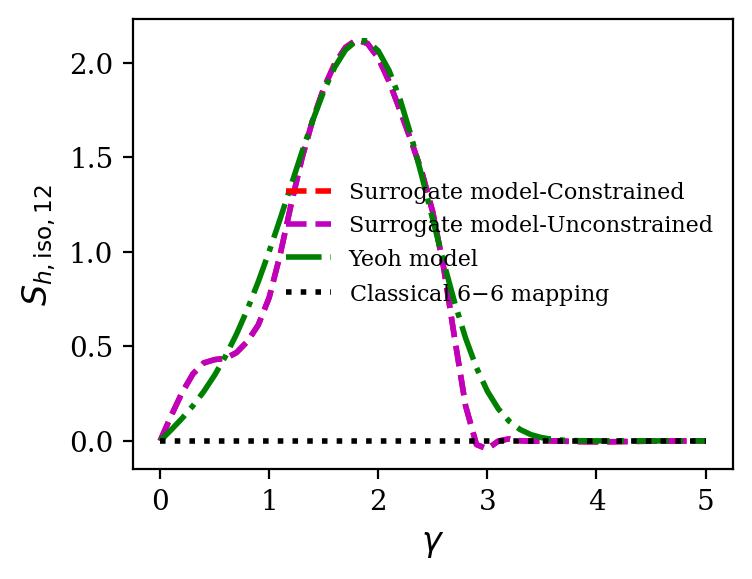

In [78]:
# Plot 3a: Model predictions in the shear testing regime_S12: GPR surrogate model, Yeoh model, and MR Model (extrapolated training data). 

fig = plt.figure(figsize=(4, 3), dpi=200)

h = [Size.Fixed(0), Size.Fixed(3)]
v = [Size.Fixed(0), Size.Fixed(2.25)]
divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# The width and height of the rectangle are ignored.
ax = fig.add_axes(divider.get_position(),
                  axes_locator=divider.new_locator(nx=1, ny=1))
fig.set_tight_layout(False)

#ax = fig.add_subplot(1, 1, 1)
# plt.xlim([0, 0.85])
# plt.ylim([0, 1.8])

#ax.plot(F12, S12_ground_truth_sh, c = 'b', linewidth = 2, label = 'Ground truth (Mooney$-$Rivlin Model)')
ax.plot(F12, S12_test_sh, c = 'r', linestyle = '--', linewidth = 2, label = 'Surrogate model-Constrained')
ax.plot(F12, S12_test_stdGPR_sh, c = 'm', linestyle = '--', linewidth = 2, label = 'Surrogate model-Unconstrained')
ax.plot(F12, S12_YH_sh, c = 'g', linestyle = '-.', linewidth = 2, label = 'Yeoh model')
ax.plot(F12, S12_test_6_6_sh, c = 'k', linestyle = ':', linewidth = 2, label = 'Classical 6$-$6 mapping')
ax.set_xlabel('$\gamma$')
ax.set_ylabel('$S_{h,\mathrm{iso, 12}}$')
ax.legend(frameon=False, prop={'size': 8})
# set_size(3,2.25)
plt.savefig("Hyperelastic_testing_shear_prediction_12.svg")
plt.show()

In [ ]:
# # Plot 3b: Model performance (errors) in the shear testing regime: GPR surrogate model, Yeoh model, and MR Model (extrapolated training data). 

# fig = plt.figure(figsize=(4, 3), dpi=200)

# h = [Size.Fixed(0), Size.Fixed(3)] # Order: [left, width]
# v = [Size.Fixed(0), Size.Fixed(2.25/2 - 0.2)] # Order: [bottom, height]
# divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)

# h2 = [Size.Fixed(0), Size.Fixed(3)] # Order: [left, width]
# v2 = [Size.Fixed(2.25/2), Size.Fixed(2.25/2)] # Order: [bottom, height]
# divider2 = Divider(fig, (0, 0, 1, 1), h2, v2, aspect=False)
# # The width and height of the rectangle are ignored.
# ax = fig.add_axes(divider.get_position(),
#                   axes_locator=divider.new_locator(nx=1, ny=1)) # ax is the bottom axis.
# ax2 = fig.add_axes(divider2.get_position(),
#                   axes_locator=divider2.new_locator(nx=1, ny=1)) # ax2 is the top axis.
# fig.set_tight_layout(False)

# ax2.set_ylim(95, 200)  # Top axis
# ax.set_ylim(0, 22)  # Bottom axis

# # The two x-axis limits defined below MUST be the idential.
# ax2.set_xlim(0, 0.82)  # Top axis
# ax.set_xlim(0, 0.82)  # Bottom axis

# # Hide the spines between ax and ax2
# ax2.spines['bottom'].set_visible(False)
# ax.spines['top'].set_visible(False)
# ax2.xaxis.tick_bottom()
# ax2.tick_params(labelbottom=False)  # don't put tick labels at the bottom
# ax2.tick_params(labeltop=False)  # don't put tick labels at the top
# ax2.tick_params(bottom=False)  # don't put tick marks at the bottom
# ax.tick_params(labeltop=False)  # don't put tick labels at the top

# d = .02  # how big to make the diagonal lines in axes coordinates
# # arguments to pass to plot, just so we don't keep repeating them
# kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False)
# ax2.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
# ax2.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

# kwargs.update(transform=ax.transAxes)  # switch to the bottom axes
# ax.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
# ax.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal

# ax.plot(F12, 100 * np.array(err_test_overall[81:]), c = 'r', linestyle = '--', linewidth = 2, label = 'Surrogate model')
# ax.plot(F12, 100 * np.array(err_YH_overall[81:]), c = 'g', linestyle = '-.', linewidth = 2, label = 'Yeoh model')
# ax2.plot(F12, 100 * np.array(err_test_6_6_overall[81:]), c = 'k', linestyle = ':', linewidth = 2, label = 'Classical 6$-$6 mapping')
# ax2.plot(F12, 100 * np.array(err_test_overall[81:]), c = 'r', linestyle = '--', linewidth = 2, label = 'Surrogate model')
# ax2.plot(F12, 100 * np.array(err_YH_overall[81:]), c = 'g', linestyle = '-.', linewidth = 2, label = 'Yeoh model')

# ax.set_xlabel('$\gamma$')
# ax2.set_ylabel('err (%)')
# ax.legend(frameon=False, prop={'size': 8})
# ax2.legend(frameon=False, prop={'size': 8})

# #plt.savefig("Hyperelastic_testing_shear_prediction_errors.svg")
# plt.show()


In [ ]:
# # Analyzing the effect of training data size on the overall percent mean relative error, from the surrogate model and the 6-6 classical mapping model.
# datasize = [26,51,76,101,126,151,176,201]
# mean_err_surrogate_training, mean_err_classical_training = [], []
# mean_err_surrogate_overall, mean_err_classical_overall = [], []

# for i in range(len(datasize)):
#     # Input training data generation: Invariants.
#     F_training = []
#     N = datasize[i]
#     F11_train = np.linspace(1, 1.25, N) # Unconfined tension
#     for i in range(N):
#         F_training.append(np.array([F11_train[i], 0, 0, 0, (1/np.sqrt(F11_train[i])), 0, 0, 0, (1/np.sqrt(F11_train[i]))]))

#     I1_training, I2_training, J_training = invariants(F_training)
#     C_training, C_bar_training = right_cauchy_green(F_training)
#     input_training = np.vstack((np.array(I1_training), np.array(I2_training))).T
    
#     # Output training data generation: Irreducible integrity bases. This data is generated artifically using the MR model.

#     A10, A01 = 1, 0.5
#     S_training = []

#     for i in range(len(F_training)):
#         S_training.append((2 * (J_training[i] ** (-2/3))) * ((A10 + (input_training[i,0] * A01)) * ref_deviatoric(np.eye(3), C_training[i]) - A01 * ref_deviatoric(C_bar_training[i], C_training[i])))

#     gamma1, gamma2 = hyperelastic_coefficients(C_training, S_training)
#     output_training = np.vstack((gamma1, gamma2)).T
    
#     Krig = GaussianProcessRegressor(kernel=kernels[4], alpha=1.0e0, n_restarts_optimizer=10, normalize_y=True)
#     Krig.fit(input_training,output_training)
#     print('GPR fit score for the surrogate model: ', Krig.score(input_training,output_training))
    
#     # Input training data generation for the classical 6-6 mapping model.
#     C11_training = [C_training[i][0,0] for i in range(len(C_training))] 
#     C12_training = [C_training[i][0,1] for i in range(len(C_training))]
#     C13_training = [C_training[i][0,2] for i in range(len(C_training))]
#     C22_training = [C_training[i][1,1] for i in range(len(C_training))]
#     C23_training = [C_training[i][1,2] for i in range(len(C_training))]
#     C33_training = [C_training[i][2,2] for i in range(len(C_training))]

#     input_train_6_6 = np.vstack((np.array(C11_training), np.array(C12_training), np.array(C13_training), np.array(C22_training),
#                              np.array(C23_training), np.array(C33_training))).T
    
#     # Output training data generation for the classical 6-6 mapping model.
#     S11_training = [S_training[i][0,0] for i in range(len(S_training))] 
#     S12_training = [S_training[i][0,1] for i in range(len(S_training))]
#     S13_training = [S_training[i][0,2] for i in range(len(S_training))]
#     S22_training = [S_training[i][1,1] for i in range(len(S_training))]
#     S23_training = [S_training[i][1,2] for i in range(len(S_training))]
#     S33_training = [S_training[i][2,2] for i in range(len(S_training))]

#     output_train_6_6 = np.vstack((np.array(S11_training), np.array(S12_training), np.array(S13_training), np.array(S22_training),
#                              np.array(S23_training), np.array(S33_training))).T
    
#     Krig_6_6 = GaussianProcessRegressor(kernel=kernels[4], alpha=1.0e-2, n_restarts_optimizer=10, normalize_y=True)
#     Krig_6_6.fit(input_train_6_6,output_train_6_6)
#     print('GPR fit score for the classical mapping model: ', Krig_6_6.score(input_train_6_6,output_train_6_6))
    
    
#     # Generating test data
#     F_test = []
#     M = (N-1)*4 + 1
#     F11 = np.linspace(0.5, 1.50, M)
#     for i in range(M):
#         F_test.append(np.array([F11[i], 0, 0, 0, 1/np.sqrt(F11[i]), 0, 0, 0, 1/np.sqrt(F11[i])]))

#     I1_test, I2_test, J_test = invariants(F_test)
#     C_test, C_bar_test = right_cauchy_green(F_test)

#     # GPR surrogate model.
#     input_test = np.vstack((np.array(I1_test), np.array(I2_test))).T
#     output_test = Krig.predict(input_test)
#     S_test = []
#     for i in range(len(F_test)):
#         S_test.append(J_test[i] ** (-2/3) * (output_test[i,0] * ref_deviatoric(np.eye(3), C_test[i]) + output_test[i,1] * ref_deviatoric(C_bar_test[i], C_test[i])))

#     S11_test, S22_test = [], []
#     for i in range(len(F_test)):
#         S11_test.append(S_test[i][0,0])
#         S22_test.append(S_test[i][1,1])
    
#     # Classical 6-6 mapping model
#     C11_test = [C_test[i][0,0] for i in range(len(C_test))] 
#     C12_test = [C_test[i][0,1] for i in range(len(C_test))]
#     C13_test = [C_test[i][0,2] for i in range(len(C_test))]
#     C22_test = [C_test[i][1,1] for i in range(len(C_test))]
#     C23_test = [C_test[i][1,2] for i in range(len(C_test))]
#     C33_test = [C_test[i][2,2] for i in range(len(C_test))]

#     input_test_6_6 = np.vstack((np.array(C11_test), np.array(C12_test), np.array(C13_test), np.array(C22_test),
#                              np.array(C23_test), np.array(C33_test))).T
#     output_test_6_6 = Krig_6_6.predict(input_test_6_6)

#     S_test_6_6 = []
#     for i in range(len(F_test)):
#         S_test_6_6.append(np.array([[output_test_6_6[i][0], output_test_6_6[i][1], output_test_6_6[i][2]],
#                                [output_test_6_6[i][1], output_test_6_6[i][3], output_test_6_6[i][4]],
#                                [output_test_6_6[i][2], output_test_6_6[i][4], output_test_6_6[i][5]]]))

#     S11_test_6_6, S22_test_6_6 = [], []
#     for i in range(len(F_test)):
#         S11_test_6_6.append(S_test_6_6[i][0,0])
#         S22_test_6_6.append(S_test_6_6[i][1,1])

#     # Extended MR Model (ground truth)
#     S_MR = []
#     for i in range(len(F_test)):
#         S_MR.append((2 * (J_test[i] ** (-2/3))) * ((A10 + (input_test[i,0] * A01)) * ref_deviatoric(np.eye(3), C_test[i]) - 
#                           A01 * ref_deviatoric(C_bar_test[i], C_test[i])))
#     S11_MR, S22_MR = [], []
#     for i in range(len(F_test)):
#         S11_MR.append(S_MR[i][0,0])
#         S22_MR.append(S_MR[i][1,1])

#     # 2-parameter Yeoh Model
#     S_YH = []
#     for i in range(len(F_test)):
#         S_YH.append(2 * (J_test[i] ** (-2/3)) * ((C1_YH + (2 * C2_YH * (input_test[i,0] - 3))) * ref_deviatoric(np.eye(3), C_test[i])))

#     S11_YH, S22_YH = [], []
#     for i in range(len(F_test)):
#         S11_YH.append(S_YH[i][0,0])
#         S22_YH.append(S_YH[i][1,1])
    
#     # Testing the accuracy of the trained GPR model in shear deformation mode.
#     F_test_sh = []
#     K = N
#     F12 = np.linspace(0, 0.5, K)
#     for i in range(K):
#         F_test_sh.append(np.array([1, F12[i], 0, 0, 1, 0, 0, 0, 1]))

#     I1_test_sh, I2_test_sh, J_test_sh = invariants(F_test_sh)
#     C_test_sh, C_bar_test_sh = right_cauchy_green(F_test_sh)
#     input_test_sh = np.vstack((np.array(I1_test_sh), np.array(I2_test_sh))).T

#     # GPR surrogate model.
#     output_test_sh = Krig.predict(input_test_sh)
#     S_test_sh = []
#     for i in range(len(F_test_sh)):
#         S_test_sh.append(J_test_sh[i] ** (-2/3) * (output_test_sh[i,0] * ref_deviatoric(np.eye(3), C_test_sh[i]) + output_test_sh[i,1] * ref_deviatoric(C_bar_test_sh[i], C_test_sh[i])))   

#     S12_test_sh = []
#     for i in range(len(F_test_sh)):
#         S12_test_sh.append(S_test_sh[i][0,1])   

#     # Classical 6-6 mapping model
#     C11_test_sh = [C_test_sh[i][0,0] for i in range(len(C_test_sh))] 
#     C12_test_sh = [C_test_sh[i][0,1] for i in range(len(C_test_sh))]
#     C13_test_sh = [C_test_sh[i][0,2] for i in range(len(C_test_sh))]
#     C22_test_sh = [C_test_sh[i][1,1] for i in range(len(C_test_sh))]
#     C23_test_sh = [C_test_sh[i][1,2] for i in range(len(C_test_sh))]
#     C33_test_sh = [C_test_sh[i][2,2] for i in range(len(C_test_sh))]

#     input_test_6_6_sh = np.vstack((np.array(C11_test_sh), np.array(C12_test_sh), np.array(C13_test_sh), np.array(C22_test_sh),
#                              np.array(C23_test_sh), np.array(C33_test_sh))).T
#     output_test_6_6_sh = Krig_6_6.predict(input_test_6_6_sh)

#     S_test_6_6_sh = []
#     for i in range(len(F_test_sh)):
#         S_test_6_6_sh.append(np.array([[output_test_6_6_sh[i][0], output_test_6_6_sh[i][1], output_test_6_6_sh[i][2]],
#                                [output_test_6_6_sh[i][1], output_test_6_6_sh[i][3], output_test_6_6_sh[i][4]],
#                                [output_test_6_6_sh[i][2], output_test_6_6_sh[i][4], output_test_6_6_sh[i][5]]]))

#     S12_test_6_6_sh = []
#     for i in range(len(F_test_sh)):
#         S12_test_6_6_sh.append(S_test_6_6_sh[i][0,1])

#     # Extended MR model (ground truth)  
#     S_MR_sh = []
#     for i in range(len(F_test_sh)):
#         S_MR_sh.append((2 * (J_test_sh[i] ** (-2/3))) * ((A10 + (input_test_sh[i,0] * A01)) * ref_deviatoric(np.eye(3), C_test_sh[i]) - 
#                           A01 * ref_deviatoric(C_bar_test_sh[i], C_test_sh[i])))

#     S12_MR_sh = []
#     for i in range(len(F_test_sh)):
#         S12_MR_sh.append(S_MR_sh[i][0,1])

#     # 2-parameter Yeoh Model
#     S_YH_sh = []
#     for i in range(len(F_test_sh)):
#         S_YH_sh.append((2 * (J_test_sh[i] ** (-2/3))) * ((C1_YH + (2 * C2_YH * (input_test_sh[i,0] - 3))) * ref_deviatoric(np.eye(3), C_test_sh[i])))

#     S12_YH_sh = []
#     for i in range(len(F_test_sh)):
#         S12_YH_sh.append(S_YH_sh[i][0,1])
    
    
#     # Combining the uniaxial and shear testing data.
#     S_test_overall = S_test + S_test_sh
#     S_test_6_6_overall = S_test_6_6 + S_test_6_6_sh
#     S_MR_overall = S_MR + S_MR_sh
#     S_YH_overall = S_YH + S_YH_sh
    
    
#     # Testing the accuracy of the trained GPR model by computing error metrics and comparing with errors from YH model and 6-6 mapping GPR model.
# # Computing error metric for the GPR surrogate model.
#     err_test_overall = []
#     for i in range(len(S_test_overall)):
#         S_diff = S_test_overall[i] - S_MR_overall[i]
#         err_test_overall.append(np.linalg.norm(S_diff) / np.linalg.norm(S_MR_overall[i]))

#     err_test_overall_ = err_test_overall.copy()
#     if inf in err_test_overall_:
#         err_test_overall_.remove(inf)

#     mean_err_trainregime = np.nanmean(np.array(err_test_overall_)[2*(N-1):3*(N-1)+1]) # mean error in the training regime of F11 = 1 to 1.25.
#     max_err_trainregime = np.nanmax(np.array(err_test_overall_)[2*(N-1):3*(N-1)+1])
#     mean_err_test = np.nanmean(np.array(err_test_overall_))# Overall mean error

#     # Computing error metric for the YH model.
#     err_YH_overall = []
#     for i in range(len(S_test_overall)):
#         S_diff = S_YH_overall[i] - S_MR_overall[i]
#         err_YH_overall.append(np.linalg.norm(S_diff) / np.linalg.norm(S_MR_overall[i]))

#     err_YH_overall_ = err_YH_overall.copy()
#     if inf in err_YH_overall_:
#         err_YH_overall_.remove(inf)

#     mean_err_trainregime_YH = np.nanmean(np.array(err_YH_overall_)[2*(N-1):3*(N-1)+1]) # mean error in the training regime of F11 = 1 to 1.25.
#     mean_err_YH = np.nanmean(np.array(err_YH_overall_))# Overall mean error

#     # Computing error metric for the 6-6 classical mapping model.
#     err_test_6_6_overall = []
#     for i in range(len(S_test_6_6_overall)):
#         S_diff = S_test_6_6_overall[i] - S_MR_overall[i]
#         err_test_6_6_overall.append(np.linalg.norm(S_diff) / np.linalg.norm(S_MR_overall[i]))


#     err_test_6_6_overall_ = err_test_6_6_overall.copy()
#     if inf in err_test_6_6_overall_:
#         # err_test_6_6_overall_.remove(inf)
#         err_test_6_6_overall_[2*(N-1)] = nan
#         err_test_6_6_overall_[4*(N-1)+1] = nan
#     # if inf in err_test_6_6_overall_:
#     #     err_test_6_6_overall_.remove(inf)
#     mean_err_trainregime_6_6 = np.nanmean(np.array(err_test_6_6_overall_)[2*(N-1):3*(N-1)+1]) # mean error in the training regime of F11 = 1 to 1.25.
#     mean_err_test_6_6 = np.nanmean(np.array(err_test_6_6_overall_))# Overall mean error
    
    
#     mean_err_surrogate_training.append(np.nanmean(np.array(err_test_overall_)[2*(N-1):3*(N-1)+1])) # mean error in the training regime of F11 = 1 to 1.25.
#     mean_err_surrogate_overall.append(np.nanmean(np.array(err_test_overall_)))# Overall mean error
        
#     mean_err_classical_training.append(np.nanmean(np.array(err_test_6_6_overall_)[2*(N-1):3*(N-1)+1])) # mean error in the training regime of F11 = 1 to 1.25.
#     mean_err_classical_overall.append(np.nanmean(np.array(err_test_6_6_overall_)))# Overall mean error

In [ ]:
# # Plots 4a and 4b: Percent mean relative error versus datasize: both training and overall (training + testing).

# fig = plt.figure(figsize=(4, 3), dpi=200)

# h = [Size.Fixed(0), Size.Fixed(3)]
# v = [Size.Fixed(0), Size.Fixed(2.25)]
# divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# # The width and height of the rectangle are ignored.
# ax = fig.add_axes(divider.get_position(),
#                   axes_locator=divider.new_locator(nx=1, ny=1))
# fig.set_tight_layout(False)

# #ax = fig.add_subplot(1, 1, 1)
# plt.xlim([0, 210])
# #plt.ylim([0, 35])

# ax.plot(datasize, 100 * np.array(mean_err_surrogate_overall), c = 'r', linestyle = '-', marker = 's',  markerfacecolor='none', markersize = '5', markeredgewidth = 1.5, linewidth = 2, label = 'Surrogate model')
# ax.plot(datasize, 100 * np.array(mean_err_classical_overall), c = 'k', linestyle = '-', marker = 'd',  markerfacecolor='none', markersize = '5', markeredgewidth = 1.5, linewidth = 2, label = 'Classical 6$-$6 mapping')

# ax.set_xlabel('$\mathrm{card}(\mathcal{D})$')
# ax.set_ylabel('$\overline{\mathrm{err}}$ (%)')
# ax.legend(frameon=False, prop={'size': 8})
# plt.savefig("Hyperelastic_testing_prediction_error versus datasize_testing.svg")
# plt.show()

# fig = plt.figure(figsize=(4, 3), dpi=200)

# h = [Size.Fixed(0), Size.Fixed(3)]
# v = [Size.Fixed(0), Size.Fixed(2.25)]
# divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# # The width and height of the rectangle are ignored.
# ax = fig.add_axes(divider.get_position(),
#                   axes_locator=divider.new_locator(nx=1, ny=1))
# fig.set_tight_layout(False)

# #ax = fig.add_subplot(1, 1, 1)
# plt.xlim([0, 210])
# plt.ylim([0, 5])


# ax.plot(datasize, 100 * np.array(mean_err_surrogate_training), c = 'r', linestyle = '--', marker = 's',  markerfacecolor='none', markersize = '5', markeredgewidth = 1.5, linewidth = 2, label = 'Surrogate model')
# ax.plot(datasize, 100 * np.array(mean_err_classical_training), c = 'k', linestyle = '--', marker = 'd',  markerfacecolor='none', markersize = '5', markeredgewidth = 1.5, linewidth = 2, label = 'Classical 6$-$6 mapping')

# ax.set_xlabel('$\mathrm{card}(\mathcal{D})$')
# ax.set_ylabel('$\overline{\mathrm{err}}$ (%)')
# ax.legend(frameon=False, prop={'size': 8})
# plt.savefig("Hyperelastic_testing_prediction_error versus datasize_training.svg")
# plt.show()

In [ ]:
# fig = plt.figure(figsize=(4, 3), dpi=200)

# h = [Size.Fixed(0), Size.Fixed(3)]
# v = [Size.Fixed(0), Size.Fixed(2.25)]
# divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# # The width and height of the rectangle are ignored.
# ax = fig.add_axes(divider.get_position(),
#                   axes_locator=divider.new_locator(nx=1, ny=1))
# fig.set_tight_layout(False)

# #ax = fig.add_subplot(1, 1, 1)
# #plt.xlim([0.48, 1])
# #plt.ylim([-20, 0])
# ax.xaxis.tick_top()
# ax.yaxis.tick_right()
# ax.xaxis.set_label_position('top') 
# ax.yaxis.set_label_position('right') 

# ax.plot(F11, S11_MR, c = 'b', linewidth = 2, label = 'Ground truth (Mooney$-$Rivlin Model)')
# ax.plot(F11, S11_test, c = 'r', linestyle = '--', linewidth = 2, label = 'Surrogate model')
# ax.plot(F11, S11_YH, c = 'g', linestyle = '-.', linewidth = 2, label = 'Yeoh model')
# ax.plot(F11, S11_test_6_6, c = 'k', linestyle = ':', linewidth = 2, label = 'Classical 6$-$6 mapping')
# ax.set_xlabel('$\lambda$')
# ax.set_ylabel('$S_{h,\mathrm{iso, 11}}$', rotation = 270, labelpad=18)
# ax.legend(frameon=False, prop={'size': 8})
# #set_size(3,2.25)
# plt.savefig("Hyperelastic_testing_maxdatasize_prediction_11.svg")
# plt.show()

In [ ]:
# fig = plt.figure(figsize = (4,3), dpi = 200)

# h = [Size.Fixed(0), Size.Fixed(3)]
# v = [Size.Fixed(0), Size.Fixed(2.25)]
# divider = Divider(fig, (0, 0, 1, 1), h, v, aspect=False)
# # The width and height of the rectangle are ignored.
# ax = fig.add_axes(divider.get_position(),
#                   axes_locator=divider.new_locator(nx=1, ny=1))
# fig.set_tight_layout(False)

# #ax = fig.add_subplot(1, 1, 1)
# #plt.xlim([0.48, 1])
# #plt.ylim([-20, 0])
# ax.xaxis.tick_top()
# ax.yaxis.tick_right()
# ax.xaxis.set_label_position('top') 
# ax.yaxis.set_label_position('right') 

# ax.plot(F11, S22_MR, c = 'b', linewidth = 2, label = 'Ground truth (Mooney$-$Rivlin Model)')
# ax.plot(F11, S22_test, c = 'r', linestyle = '--', linewidth = 2, label = 'Surrogate model')
# ax.plot(F11, S22_YH, c = 'g', linestyle = '-.', linewidth = 2, label = 'Yeoh model')
# ax.plot(F11, S22_test_6_6, c = 'k', linestyle = ':', linewidth = 2, label = 'Classical 6$-$6 mapping')
# ax.set_xlabel('$\lambda$')
# ax.set_ylabel('$S_{h,\mathrm{iso, 11}}$', rotation = 270, labelpad=18)
# ax.legend(frameon=False, prop={'size': 8})
# # set_size(3,2.25)
# plt.savefig("Hyperelastic_testing_maxdatasize_prediction_22.svg")
# plt.show()

In [ ]:
# Monte-Carlo Sampling
n_samples_MC = 10000
F_MC = F_space.rvs(n_samples_MC)
I1_MC, I2_MC, I3_MC, _ = invariants(F_MC)

In [ ]:
# Sobol Sampling
n_samples_sobol = 256
sobol = Sobol()
F_sobol = sobol.generate(F_space.dimensions, n_samples_sobol)
I1_sobol, I2_sobol, I3_sobol, _ = invariants(F_sobol)

In [ ]:
# LHS maximin Sampling
n_samples_LHS = 256
lhs = Lhs(criterion="maximin", iterations=10000)
F_lhs = lhs.generate(F_space.dimensions, n_samples_LHS)
I1_lhs, I2_lhs, I3_lhs, _ = invariants(F_lhs)

In [ ]:
# Halton Sampling
n_samples_halton = 256
halton = Halton()
F_halton = halton.generate(F_space.dimensions, n_samples_halton)
I1_halton, I2_halton, I3_halton, _ = invariants(F_halton)

In [ ]:
# Hammersly Sampling
n_samples_hammersly = 256
hammersly = Hammersly()
F_hammersly = hammersly.generate(F_space.dimensions, n_samples_hammersly)
I1_hammersly, I2_hammersly, I3_hammersly, _ = invariants(F_hammersly)

In [ ]:
# for creating a responsive plot
%matplotlib widget
# importing required libraries
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(4, 4))
ax = Axes3D(fig)
#ax = fig.add_subplot(projection='3d')
sc = ax.scatter(I1_MC, I2_MC, I3_MC, c='b', marker = '.', alpha = 0.1)
sc_2 = ax.scatter(I1_sobol, I2_sobol, I3_sobol, c='r', s=24)
plt.show()

In [ ]:
fig, axs = plt.subplots(3, 4, figsize=(15, 12))

axs[0,0].scatter(I1_MC, I2_MC,c='b', marker='.')
axs[0,0].scatter(I1_sobol, I2_sobol,c='r', marker='.')
axs[0,0].set_title('Sobol Sampling')
axs[0,1].scatter(I1_MC, I2_MC,c='b', marker='.')
axs[0,1].scatter(I1_lhs, I2_lhs,c='r', marker='.')
axs[0,1].set_title('LHS Minimax Sampling')
axs[0,2].scatter(I1_MC, I2_MC,c='b', marker='.')
axs[0,2].scatter(I1_halton, I2_halton,c='r', marker='.')
axs[0,2].set_title('Halton Sampling')
axs[0,3].scatter(I1_MC, I2_MC,c='b', marker='.')
axs[0,3].scatter(I1_hammersly, I2_hammersly,c='r', marker='.')
axs[0,3].set_title('Hammerly Sampling')

axs[1,0].scatter(I2_MC, I3_MC,c='b', marker='.')
axs[1,0].scatter(I2_sobol, I3_sobol,c='r', marker='.')
axs[1,1].scatter(I2_MC, I3_MC,c='b', marker='.')
axs[1,1].scatter(I2_lhs, I3_lhs,c='r', marker='.')
axs[1,2].scatter(I2_MC, I3_MC,c='b', marker='.')
axs[1,2].scatter(I2_halton, I3_halton,c='r', marker='.')
axs[1,3].scatter(I2_MC, I3_MC,c='b', marker='.')
axs[1,3].scatter(I2_hammersly, I3_hammersly,c='r', marker='.')

axs[2,0].scatter(I3_MC, I1_MC,c='b', marker='.')
axs[2,0].scatter(I3_sobol, I1_sobol,c='r', marker='.')
axs[2,1].scatter(I3_MC, I1_MC,c='b', marker='.')
axs[2,1].scatter(I3_lhs, I1_lhs,c='r', marker='.')
axs[2,2].scatter(I3_MC, I1_MC,c='b', marker='.')
axs[2,2].scatter(I3_halton, I1_halton,c='r', marker='.')
axs[2,3].scatter(I3_MC, I1_MC,c='b', marker='.')
axs[2,3].scatter(I3_hammersly, I1_hammersly,c='r', marker='.')
# axs[2].scatter(I3_lhs, I1_lhs,c='c', marker='.')
# axs[2].scatter(I3_halton, I1_halton,c='k', marker='.')
# axs[2].scatter(I3_hammersly, I1_hammersly,c='y', marker='.')
# axs[2].set_xlabel('I3')
# axs[2].set_ylabel('I1')
# axs[2].legend(['MC', 'QMC-Sobol', 'QMC-LHS', 'QMC-Halton', 'QMC-Hammersly'])

In [ ]:
# Now, based on the above plots, select a method of sampling and choose the corresponding invariants for training
# data generation. I choose Sobol Sampling as of now (limitation is that it can only generate 2^n samples)

I1_data, I2_data, I3_data = np.array(I1_sobol), np.array(I2_sobol), np.array(I3_sobol)

In [ ]:
# Now generate corresponding Second PK stress data using a chosen hyperelastic model. For now, I choose the
# Mooney-Rivlin (MR) Model (Also used in Nikolaos's paper).

A10, A01, k = 1, 1, 1 # Model parameters of the MR model

C1_MR_data = (2 * A10 + (2 * A01*I1_data)) # Irreducible integrity basis of the MR model
C2_MR_data = -2 * A01 * np.ones(C1_MR_data.shape)

J_data = np.sqrt(I3_data)
C3_MR_data = (2 * k * J_data * (J_data - 1)) - (2*(A10 + 2*A01))

In [ ]:
# Finalize the input-output data for training the GPR model
input_train = np.vstack((I1_data, I2_data, I3_data)).T
output_train = np.vstack((C1_MR_data, C2_MR_data, C3_MR_data)).T

In [ ]:
# Building the GPR model
kernels = [ConstantKernel(1.0, (1e-4, 1e4)) * RBF(1, (1e-4, 1e4)),
           1.0 * RationalQuadratic(length_scale=1.0, alpha=0.1),
           1.0 * ExpSineSquared(length_scale=1.0, periodicity=1,
                                length_scale_bounds=(1.0e-5, 100.0),
                                periodicity_bounds=(1.0, 10.0)),
           ConstantKernel(0.1, (0.01, 10.0))
           * (DotProduct(sigma_0=1.0, sigma_0_bounds=(0.0, 10.0)) ** 2),
           1.0 * Matern(length_scale=1.0, nu=1.5)]

GPR_MR = GaussianProcessRegressor(kernel=kernels[0], alpha=1.0e-2, n_restarts_optimizer=20, normalize_y=True)

GPR_MR.fit(input_train,output_train)

In [ ]:
# Testing the model prediction on sampled inputs from a different samples. Here, I am using the LHS-generated samples.
input_test = np.vstack((np.array(I1_lhs), np.array(I2_lhs), np.array(I3_lhs))).T
output_test = GPR_MR.predict(input_test)

input_labels, output_labels = ['I1', 'I2', 'I3'], ['C1', 'C2', 'C3']
for pair in list(product(range(input_train.shape[1]), range(input_train.shape[1]))):
    fig, ax = plt.subplots()
    ax.scatter(input_train[:,pair[0]], output_train[:,pair[1]],c = 'b',marker ='.')
    ax.scatter(input_test[:,pair[0]], output_test[:,pair[1]],c = 'r',marker ='.')
    ax.set_xlabel(input_labels[pair[0]])
    ax.set_ylabel(output_labels[pair[1]])
plt.show()

In [ ]:
# Testing the model prediction on a uniaxial (strain) tension-compression experiment (all other directions have no deformation)
F_uniaxial = []
N = 500
F11 = np.linspace(0.25, 1.75, N)
for i in range(N):
    F_uniaxial.append(np.array([F11[i], 0, 0, 0, 1, 0, 0, 0, 1]))
    
I1_uniaxial, I2_uniaxial, I3_uniaxial, C_uniaxial = invariants(F_uniaxial)
input_uniaxial = np.vstack((np.array(I1_uniaxial), np.array(I2_uniaxial), np.array(I3_uniaxial))).T

C1_uniaxial_MR = (2 * A10 + (2 * A01*np.array(I1_uniaxial))) # Irreducible integrity basis of the MR model
C2_uniaxial_MR = -2 * A01 * np.ones(C1_uniaxial_MR.shape)
J_uniaxial_MR = np.sqrt(I3_uniaxial)
C3_uniaxial_MR = (2 * k * J_uniaxial_MR * (J_uniaxial_MR - 1)) - (2*(A10 + 2*A01))

In [ ]:
# Calculating predicted stress from the GPR model.
output_uniaxial = GPR_MR.predict(input_uniaxial)
stress_uniaxial_pred = []
for i in range(N):
    stress_temp = (output_uniaxial[i,0] * np.eye(3)) + (output_uniaxial[i,1] * C_uniaxial[i]) + (output_uniaxial[i,2] * np.linalg.inv(C_uniaxial[i]))
    stress_uniaxial_pred.append(stress_temp)
    
# Calculating predicted stress from the original hyperelastic MR model.
stress_uniaxial_MR = []
for i in range(N):
    stress_temp = (C1_uniaxial_MR[i] * np.eye(3)) + (C2_uniaxial_MR[i] * C_uniaxial[i]) + (C3_uniaxial_MR[i] * np.linalg.inv(C_uniaxial[i]))
    stress_uniaxial_MR.append(stress_temp)


In [ ]:
S11_unaxial_pred = [stress_uniaxial_pred[i][0,0] for i in range(N)]
S11_unaxial_MR = [stress_uniaxial_MR[i][0,0] for i in range(N)]

plt.plot(F11, S11_unaxial_pred, c = 'b')
plt.plot(F11, S11_unaxial_MR, c = 'r')

plt.plot([0.2, 1.8], [0, 0], c = 'k')
plt.plot([1, 1], [-100, 100], c = 'k')
plt.xlim([0.2, 1.8])
plt.ylim([-100, 10])
plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.optimize import minimize
# from scipy.spatial.distance import cdist

# # import matplotlib
# # matplotlib.use("TkAgg")
# # import matplotlib.pyplot as plt
# # print("Matplotlib backend:", matplotlib.get_backend())


# # === Matern 5/2 Kernel and Derivatives ===
# def rbf_kernel(x1, x2, lengthscale, variance):
#     x1 = np.atleast_2d(x1)
#     x2 = np.atleast_2d(x2)
#     r = np.linalg.norm(x1[:, None] - x2[None, :], axis=-1) + 1e-12
#     sqrt5_r = np.sqrt(5) * r / lengthscale
#     return variance * (1 + sqrt5_r + 5 * r**2 / (3 * lengthscale**2)) * np.exp(-sqrt5_r)

# def rbf_kernel_dx(x1, x2, lengthscale, variance):
#     x1 = np.atleast_2d(x1)
#     x2 = np.atleast_2d(x2)
#     diff = x1[:, None, :] - x2[None, :, :]
#     r = np.linalg.norm(diff, axis=-1) + 1e-12
#     sqrt5_r = np.sqrt(5) * r / lengthscale
#     exp_term = np.exp(-sqrt5_r)
#     coef = -5 * variance / (3 * lengthscale**2)
#     # We need ∂k/∂x' (derivative w.r.t. the SECOND argument).
#     # Since for stationary kernels ∂k/∂x' = -∂k/∂x, take the negative of dk/dx.
#     return coef * diff.squeeze(-1) * (1 + sqrt5_r) * exp_term

# def rbf_kernel_dxdx(x1, x2, lengthscale, variance):
#     x1 = np.atleast_2d(x1)
#     x2 = np.atleast_2d(x2)
#     diff = x1[:, None, :] - x2[None, :, :]
#     r = np.linalg.norm(diff, axis=-1) + 1e-12
#     sqrt5_r = np.sqrt(5) * r / lengthscale
#     exp_term = np.exp(-sqrt5_r)
#     term1 = 5 / (3 * lengthscale**2)
#     term2 = 25 * diff.squeeze(-1)**2 / (3 * lengthscale**4)
#     return variance * exp_term * (term1 * (1 + sqrt5_r) - term2)
# def neg_log_marginal_likelihood(params, X, Y):
#     lengthscale, variance, noise = np.exp(params)
#     K = rbf_kernel(X, X, lengthscale, variance) + noise * np.eye(len(X))
#     L = np.linalg.cholesky(K + 1e-3 * np.eye(len(K)))
#     alpha = np.linalg.solve(L.T, np.linalg.solve(L, Y))
#     log_likelihood = -0.5 * Y.T @ alpha - np.sum(np.log(np.diag(L))) - 0.5 * len(X) * np.log(2*np.pi)
#     return -log_likelihood.flatten()[0]

# def nonnegativity_constraint(params, X_train, Y_train, X_constrain):
#     lengthscale, variance, noise = np.exp(params)
#     K = rbf_kernel(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
#     Ks = rbf_kernel(X_constrain, X_train, lengthscale, variance)
#     Kss = rbf_kernel(X_constrain, X_constrain, lengthscale, variance)
#     jitter = 1e-3
#     L = np.linalg.cholesky(K + jitter * np.eye(len(K)))
#     alpha = np.linalg.solve(L.T, np.linalg.solve(L, Y_train))
#     mean = Ks @ alpha
#     v = np.linalg.solve(L, Ks.T)
#     var = np.diag(Kss - v.T @ v).reshape(-1, 1)
#     constraint_value = mean - 2.0 * np.sqrt(var)
#     return constraint_value.flatten()

# def derivative_constraint(params, X_train, Y_train, X_constrain):
#     lengthscale, variance, noise = np.exp(params)
#     K = rbf_kernel(X_train, X_train, lengthscale, variance) + noise * np.eye(len(X_train))
#     Ks = rbf_kernel_dx(X_constrain, X_train, lengthscale, variance)
#     Kss = rbf_kernel_dxdx(X_constrain, X_constrain, lengthscale, variance)
#     L = np.linalg.cholesky(K + 1e-3 * np.eye(len(K)))
#     alpha = np.linalg.solve(L.T, np.linalg.solve(L, Y_train))
#     mean_dy_dx = Ks @ alpha
#     v = np.linalg.solve(L, Ks.T)
#     var_dy_dx = np.diag(Kss - v.T @ v).reshape(-1, 1)
#     constraint_value = mean_dy_dx + 2.0 * np.sqrt(var_dy_dx)
#     #print("Derivative means at constraint points:", mean_dy_dx.flatten()[:])  # sanity check first 10 values
#     return -constraint_value.flatten()

# # === Training Data ===
# X_train = np.array([[0.1], [0.23], [0.3], [0.5], [0.7], [0.8], [0.9], [1.1], [1.2], [1.3]])
# Y_train = np.array([[1.0], [1.1], [1.25], [0.8], [0.6], [0.0], [0.0], [0.0], [0.0], [0.0]])
# X_constrain = np.linspace(0.1, 1.5, 10)[:, None]

# # === Monotonic GPR Optimization ===
# x0 = np.log([1.0, 1.0, 1e-2])  # small noise for near-exact inference

# cons = (
#     {'type': 'ineq', 'fun': lambda p: derivative_constraint(p, X_train, Y_train, X_constrain)},
#     {'type': 'ineq', 'fun': lambda p: nonnegativity_constraint(p, X_train, Y_train, X_constrain)}
# )

# import time
# print("Starting SLSQP optimization...")
# start = time.time()
# res_mono = minimize(
#     neg_log_marginal_likelihood,
#     x0,
#     args=(X_train, Y_train),
#     constraints=cons,
#     method='SLSQP',
#     #method='COBYLA',
#     options={'disp': True, 'maxiter': 2000}
# )
# print("Finished SLSQP in", time.time() - start, "seconds")
# print("SLSQP success:", res_mono.success, "Message:", res_mono.message)
# lengthscale_mono, variance_mono = np.exp(res_mono.x[:2])
# noise_mono = 1e-2  # fixed small noise for monotonic GPR

# # === Standard GPR Optimization ===
# res_std = minimize(
#     neg_log_marginal_likelihood,
#     x0,
#     args=(X_train, Y_train),
#     method='L-BFGS-B',
#     options={'disp': True, 'maxiter': 200}
# )
# lengthscale_std, variance_std = np.exp(res_std.x[:2])
# noise_std = 1e-2  # fixed small noise for standard GPR

# # === Prediction ===
# X_test = np.linspace(0.05, 2.0, 300)[:, None]

# # Monotonic GPR
# K_mono = rbf_kernel(X_train, X_train, lengthscale_mono, variance_mono) + noise_mono * np.eye(len(X_train))
# K_s_mono = rbf_kernel(X_test, X_train, lengthscale_mono, variance_mono)
# K_ss_mono = rbf_kernel(X_test, X_test, lengthscale_mono, variance_mono)
# L_mono = np.linalg.cholesky(K_mono + 1e-3 * np.eye(len(K_mono)))
# alpha_mono = np.linalg.solve(L_mono.T, np.linalg.solve(L_mono, Y_train))
# mu_mono = K_s_mono @ alpha_mono
# v_mono = np.linalg.solve(L_mono, K_s_mono.T)
# var_mono = np.diag(K_ss_mono - v_mono.T @ v_mono).reshape(-1, 1)

# # Standard GPR
# K_std = rbf_kernel(X_train, X_train, lengthscale_std, variance_std) + noise_std * np.eye(len(X_train))
# K_s_std = rbf_kernel(X_test, X_train, lengthscale_std, variance_std)
# K_ss_std = rbf_kernel(X_test, X_test, lengthscale_std, variance_std)
# L_std = np.linalg.cholesky(K_std + 1e-3 * np.eye(len(K_std)))
# alpha_std = np.linalg.solve(L_std.T, np.linalg.solve(L_std, Y_train))
# mu_std = K_s_std @ alpha_std
# v_std = np.linalg.solve(L_std, K_s_std.T)
# var_std = np.diag(K_ss_std - v_std.T @ v_std).reshape(-1, 1)

# # === Plot ===
# plt.figure(figsize=(12, 6))
# plt.plot(X_test, mu_mono, label='Monotonic GPR Mean', linewidth=2)
# plt.fill_between(X_test.flatten(),
#                  mu_mono.flatten() - 2*np.sqrt(var_mono.flatten()),
#                  mu_mono.flatten() + 2*np.sqrt(var_mono.flatten()),
#                  alpha=0.05, label='Monotonic 95% CI')
# plt.plot(X_test, mu_std, label='Standard GPR Mean', linestyle='--', linewidth=2)
# plt.fill_between(X_test.flatten(),
#                  mu_std.flatten() - 2*np.sqrt(var_std.flatten()),
#                  mu_std.flatten() + 2*np.sqrt(var_std.flatten()),
#                  alpha=0.2, label='Standard 95% CI')
# plt.scatter(X_train, Y_train, color='red', label='Training Data')
# plt.title('Comparison: Monotonic vs Standard GPR (Matern 5/2 Kernel)')
# plt.xlabel('x')
# plt.ylabel('y')
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# print("Rendering plot...")
# #plt.savefig("gpr_monotonic_vs_standard.png", dpi=150)
# plt.show()
# #print("Saved figure as gpr_monotonic_vs_standard.png")

